<a href="https://colab.research.google.com/github/jan1jacob2/Loan-Status/blob/master/Model_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Choosing the Best Model

In [ ]:
! pip install xgboost

In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV, TunedThresholdClassifierCV
from sklearn.metrics import classification_report, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loanDF = pd.read_csv('./data/loan.csv.')
loanDF = pd.read_csv('loan.csv')
loanDF.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [3]:
onehot = pd.get_dummies(loanDF['purpose'], dtype = int)
loanDF = pd.concat([onehot, loanDF.drop(['purpose'], axis = 1)], axis = 1)
loanDF.head()

,all_other,credit_card,debt_consolidation,educational,home_improvement,major_purchase,small_business,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,0,0,1,0,0,0,0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,0,1,0,0,0,0,0,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,0,0,1,0,0,0,0,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,0,0,1,0,0,0,0,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,0,1,0,0,0,0,0,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
loanDF.shape

(9578, 20)

In [5]:
X = loanDF.iloc[:, :-1]
y = loanDF.iloc[:, -1]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = .2, random_state = 42)

In [30]:
# The columns HTuned and TTuned will contain the metric it was tuned on.
# If no tuning happened, then the value will say 'No'.
statsTrain = pd.read_csv('statsTrain.csv').iloc[:, 1:]
statsTest = pd.read_csv('statsTest.csv').iloc[:, 1:]
statsTrain['Params'] = statsTrain['Params'].apply(ast.literal_eval)
statsTest['Params'] = statsTest['Params'].apply(ast.literal_eval)

In [69]:
# Save state
statsTrain.to_csv('statsTrain.csv')
statsTest.to_csv('statsTest.csv')

In [8]:
def modelRunTrain(name, model):
  model.fit(Xtrain, ytrain)

  trainPreds = model.predict(Xtrain)

  print(f'Classification report for {name} training set \n \n {classification_report(ytrain, trainPreds)}')

  modelTrainConMat = confusion_matrix(ytrain, trainPreds)
  modelTrainDisplay = ConfusionMatrixDisplay(confusion_matrix = modelTrainConMat)
  modelTrainDisplay.plot()

  plt.show()

  return trainPreds, modelTrainConMat

In [9]:
def modelRunTest(name, model):
  testPreds = model.predict(Xtest)

  print(f'Classification report for {name} testing set \n \n {classification_report(ytest, testPreds)}')

  modelTestConMat = confusion_matrix(ytest, testPreds)
  modelTestDisplay = ConfusionMatrixDisplay(confusion_matrix = modelTestConMat)
  modelTestDisplay.plot()

  plt.show()

  return testPreds, modelTestConMat

In [10]:
def plotRocTrain(name, trainPreds):
  fpr, tpr, thresholds = roc_curve(ytrain, trainPreds)
  plt.plot(fpr, tpr)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{name} ROC Curve for Training')
  plt.show()

In [11]:
def plotRocTest(name, testPreds):
  fpr, tpr, thresholds = roc_curve(ytest, testPreds)
  plt.plot(fpr, tpr)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{name} ROC Curve for Testing')
  plt.show()

In [12]:
def addToTrainDF(name, model, hMetric, tMetric, confusionMatrix):
  if tMetric == 'No':
    threshold = .5
  else:
    threshold = round(model.best_threshold_, 4)

  if hMetric != 'No'  and tMetric == 'No':
    params = model.best_params_
  elif hMetric != 'No' and tMetric != 'No':
    params = {'Parameters': f'See {name} HTuned {hMetric}'}
  else:
    params = {'Parameters': 'Basic model was used'}


  statsTrain.loc[len(statsTrain)] = [name, hMetric, params, tMetric, threshold,
                       confusionMatrix[1][1], confusionMatrix[0][0],
                       confusionMatrix[0][1], confusionMatrix[1][0]]

In [13]:
def addToTestDF(name, model, hMetric, tMetric, confusionMatrix):
  if tMetric == 'No':
    threshold = .5
  else:
    threshold = round(model.best_threshold_, 4)

  if hMetric != 'No'  and tMetric == 'No':
    params = model.best_params_
  elif hMetric != 'No' and tMetric != 'No':
    params = {'Parameters': f'See {name} HTuned {hMetric}'}
  else:
    params = {'Parameters': 'Basic model was used'}

  statsTest.loc[len(statsTest)] = [name, hMetric, params, tMetric, threshold,
                       confusionMatrix[1][1], confusionMatrix[0][0],
                       confusionMatrix[0][1], confusionMatrix[1][0]]

In [14]:
def checkExistence(stats, name, hMetric, tMetric):
  c1 = stats['Model'] == name
  c2 = stats['HTuned'] == hMetric
  c3 = stats['TTuned'] == tMetric

  return stats[c1 & c2 & c3]

In [15]:
def viewTrainResults(name, model, hMetric, tMetric):

  if hMetric == 'No' and tMetric != 'No':
    title = f'{name} TTuned {tMetric}'
  elif hMetric != 'No' and tMetric == 'No':
    title = f'{name} HTuned {hMetric}'
  elif hMetric != 'No' and tMetric != 'No':
    title = f'{name} HTuned {hMetric} TTuned {tMetric}'
  else:
    title = name

  trainPreds, trainConMat = modelRunTrain(title, model)
  plotRocTrain(title, trainPreds)

  if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
    addToTrainDF(name, model, hMetric, tMetric, trainConMat)


In [16]:
def viewTestResults(name, model, hMetric, tMetric):

  if hMetric == 'No' and tMetric != 'No':
    title = f'{name} TTuned {tMetric}'
  elif hMetric != 'No' and tMetric == 'No':
    title = f'{name} HTuned {hMetric}'
  elif hMetric != 'No' and tMetric != 'No':
    title = f'{name} HTuned {hMetric} TTuned {tMetric}'
  else:
    title = name

  testPreds, testConMat = modelRunTest(title, model)
  plotRocTest(title, testPreds)

  if len(checkExistence(statsTest, name, hMetric, tMetric)) == 0:
    addToTestDF(name, model, hMetric, tMetric, testConMat)

In [17]:
def makeStatsDictionary():

  d = {}
  d["Train Accuracy"] = []
  d["Test Accuracy"] = []
  d["Train Balanced Accuracy"] = []
  d["Test Balanced Accuracy"] = []
  d["Train Recall"] = []
  d["Test Recall"] = []
  d["Train Specificity"] = []
  d["Test Specificity"] = []

  return d

In [18]:
def getStats(model, d):
  model.fit(Xtrain, ytrain)
  trainConMat = confusion_matrix(ytrain, model.predict(Xtrain))
  testConMat = confusion_matrix(ytest, model.predict(Xtest))

  d["Train Accuracy"].append(((trainConMat[0][0] + trainConMat[1][1]) / len(Xtrain)).item())
  d["Test Accuracy"].append(((testConMat[0][0] + testConMat[1][1]) / len(Xtest)).item())

  recTrain = (trainConMat[1][1] / (trainConMat[1][0] + trainConMat[1][1])).item()
  recTest = (testConMat[1][1] / (testConMat[1][0] + testConMat[1][1])).item()
  specTrain = (trainConMat[0][0] / (trainConMat[0][1] + trainConMat[0][0])).item()
  specTest = (testConMat[0][0] / (testConMat[0][1] + testConMat[0][0])).item()

  d["Train Balanced Accuracy"].append((recTrain + specTrain) / 2)
  d["Test Balanced Accuracy"].append((recTest + specTest) / 2)
  d["Train Recall"].append(recTrain)
  d["Test Recall"].append(recTest)
  d["Train Specificity"].append(specTrain)
  d["Test Specificity"].append(specTest)

In [19]:
def plotAccs(iterable, d, title, hTuner, acc):
  if acc:
    plt.plot(iterable, d[f"Train Accuracy"], label = f'Train Accuracy')
    plt.plot(iterable, d[f"Test Accuracy"], label = f'Test Accuracy')
    plt.ylabel("Accuracy")
  else:
    plt.plot(iterable, d[f"Train Balanced Accuracy"], label = f'Train Balanced Accuracy')
    plt.plot(iterable, d[f"Test Balanced Accuracy"], label = f'Test Balanced Accuracy')
    plt.ylabel("Balanced Accuracy")

  plt.xlabel(hTuner)
  plt.legend()
  plt.title(title)
  #plt.xticks(iterable)
  plt.show()

In [20]:
def plotSpecRec(iterable, d, title, hTuner):
  plt.plot(iterable, d["Train Specificity"], label = 'Train Specificity')
  plt.plot(iterable, d["Test Specificity"], label = 'Test Specificity')
  plt.plot(iterable, d["Train Recall"], label = 'Train Recall')
  plt.plot(iterable, d["Test Recall"], label = 'Test Recall')
  plt.xlabel(hTuner)
  plt.ylabel('Value')
  plt.legend()
  plt.title(title)
  #plt.xticks(iterable)
  plt.show()

## Logistic Regression

In [ ]:
name = 'Logistic Regression'

In [ ]:
def probDistTrainLogReg(name, model):
  probTrain = model.predict_proba(Xtrain)[:, 1]
  sns.histplot(x = probTrain, hue = ytrain, kde = True)
  plt.xlabel('Probabilities')
  plt.title(f'Probability Distribution Chart for {name} Training Set')
  plt.show()

In [ ]:
def probDistTestLogReg(name, model):
  probTest = model.predict_proba(Xtest)[:, 1]
  sns.histplot(x = probTest, hue = ytest, kde = True)
  plt.xlabel('Probabilities')
  plt.title(f'Probability Distribution Chart for {name} Testing Set')
  plt.show()

### No Tuning

Classification report for Logistic Regression training set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      6434
           1       0.45      0.01      0.01      1228

    accuracy                           0.84      7662
   macro avg       0.65      0.50      0.46      7662
weighted avg       0.78      0.84      0.77      7662



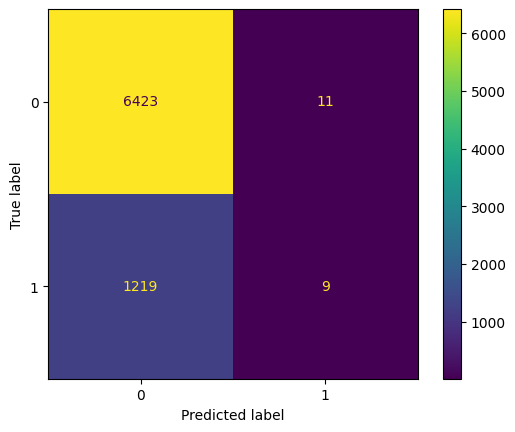

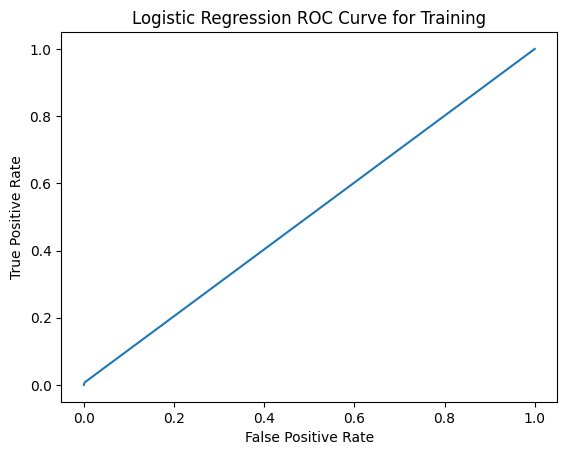

In [ ]:
hMetric = 'No'
tMetric = 'No'

logReg = LogisticRegression()
viewTrainResults(name, logReg, hMetric, tMetric)

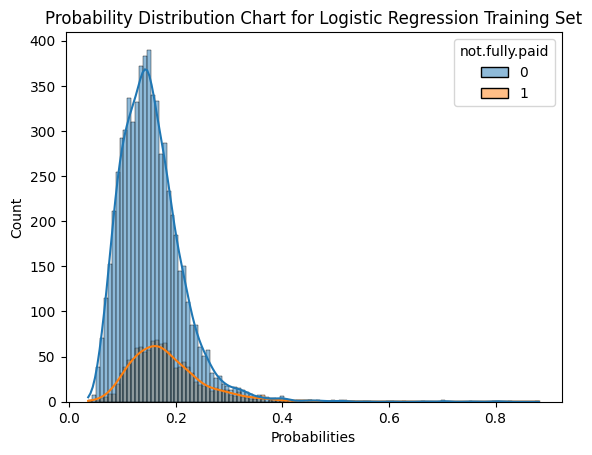

In [ ]:
probDistTrainLogReg(name, logReg)

Classification report for Logistic Regression testing set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.71      0.02      0.03       305

    accuracy                           0.84      1916
   macro avg       0.78      0.51      0.47      1916
weighted avg       0.82      0.84      0.77      1916



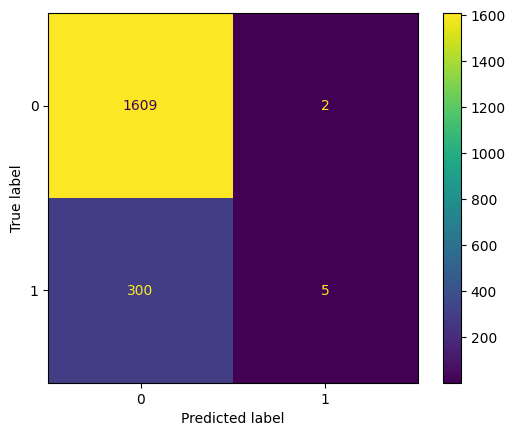

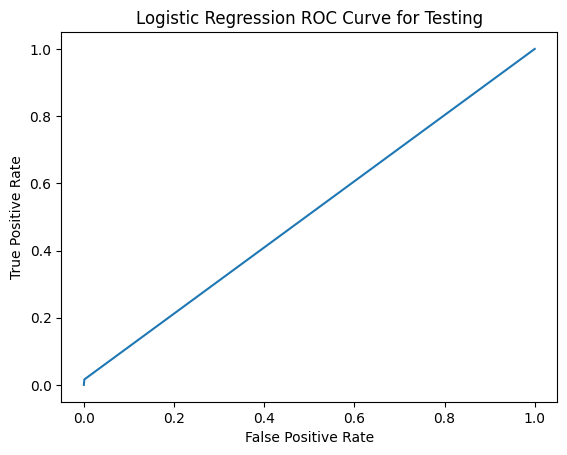

In [ ]:
viewTestResults(name, logReg, hMetric, tMetric)

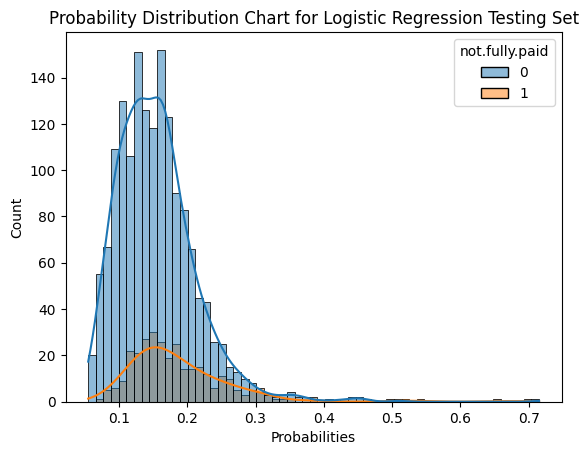

In [ ]:
probDistTestLogReg(name, logReg)

### With Hyperparameter Tuning

In [ ]:
logRegParams = {'penalty': ['l1', 'l2', None],
                'tol': [.00001, .001, .05],
                'C': [.0005, .001, 1],
                'solver': ['liblinear', 'lbfgs', 'newton-cg'],
                'l1_ratio': [.1, .33, .66, .9]}

hMetric = 'Balanced Accuracy'

Classification report for Logistic Regression HTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.89      0.65      0.75      6434
           1       0.24      0.59      0.34      1228

    accuracy                           0.64      7662
   macro avg       0.57      0.62      0.55      7662
weighted avg       0.79      0.64      0.69      7662



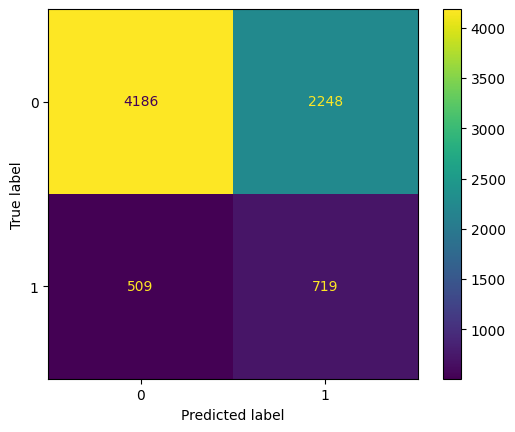

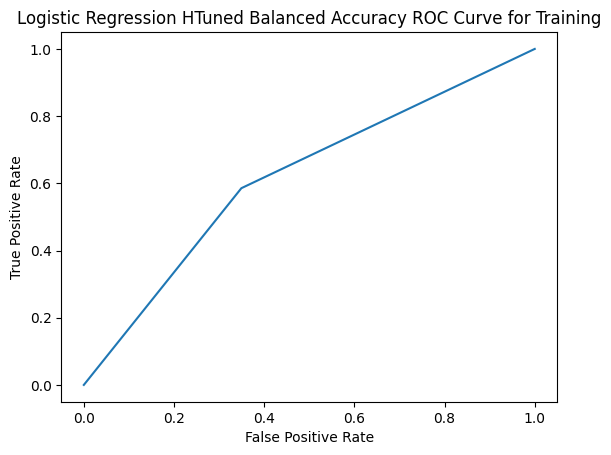

In [ ]:
if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  logRegHbacc = GridSearchCV(LogisticRegression(class_weight = 'balanced'), param_grid = logRegParams, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  logRegHbacc = GridSearchCV(LogisticRegression(class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')

viewTrainResults(name, logRegHbacc, hMetric, tMetric)

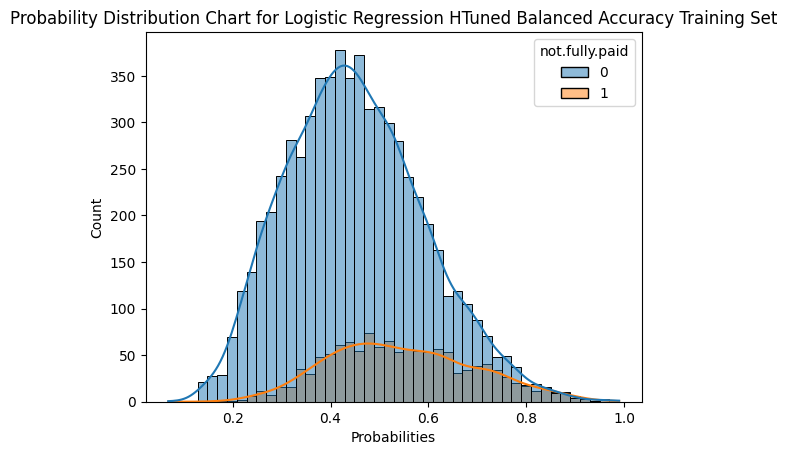

In [ ]:
probDistTrainLogReg(f'{name} HTuned {hMetric}', logRegHbacc)

Classification report for Logistic Regression HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1611
           1       0.27      0.66      0.38       305

    accuracy                           0.66      1916
   macro avg       0.59      0.66      0.57      1916
weighted avg       0.81      0.66      0.70      1916



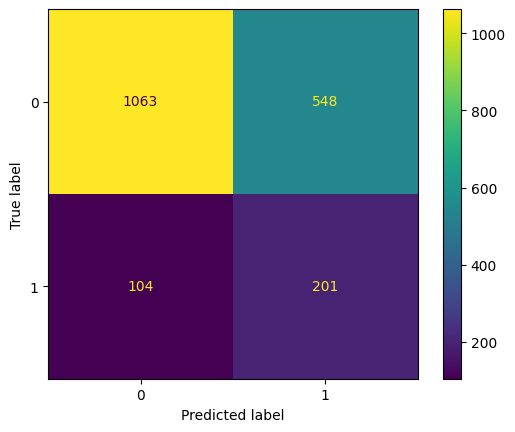

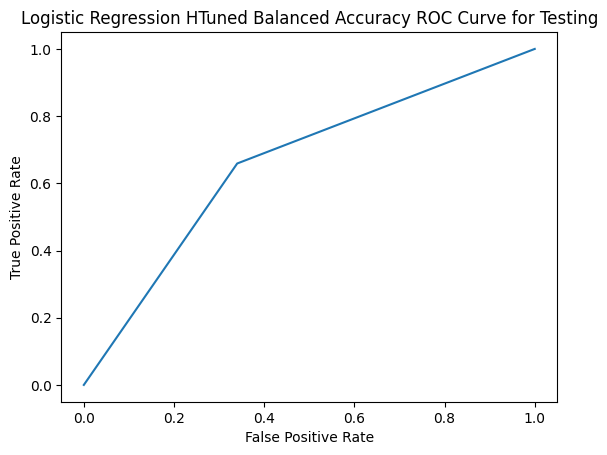

In [ ]:
viewTestResults(name, logRegHbacc, hMetric, tMetric)

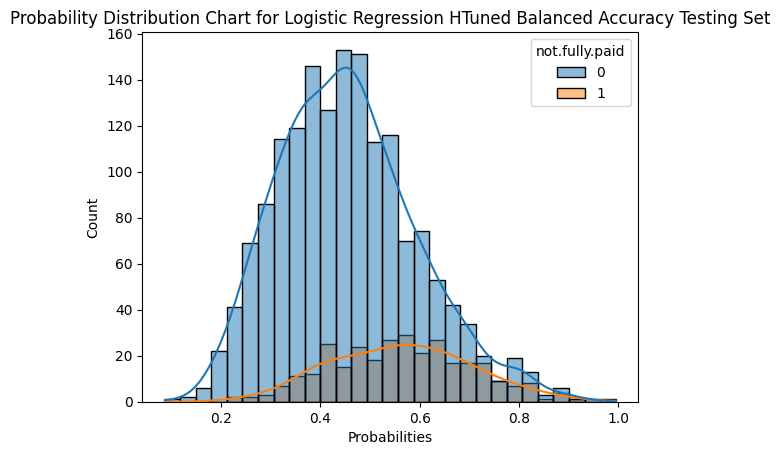

In [ ]:
probDistTestLogReg(f'{name} HTuned {hMetric}', logRegHbacc)

### With Threshold Tuning

Classification report for Logistic Regression HTuned Balanced Accuracy TTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.90      0.55      0.68      6434
           1       0.23      0.70      0.34      1228

    accuracy                           0.57      7662
   macro avg       0.57      0.62      0.51      7662
weighted avg       0.80      0.57      0.63      7662



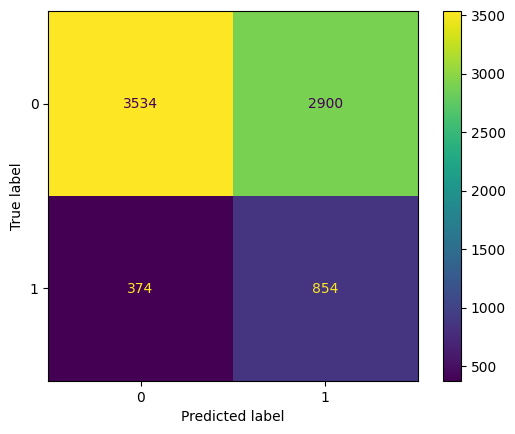

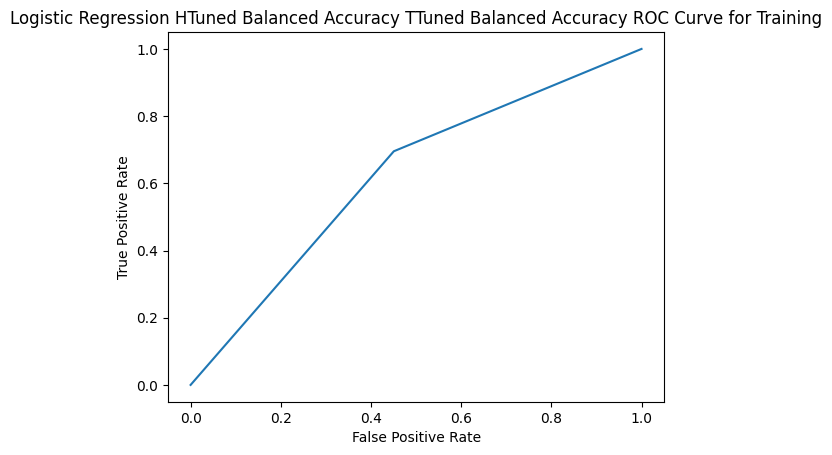

In [ ]:
tMetric = 'Balanced Accuracy'

logRegHbaccTbacc = TunedThresholdClassifierCV(logRegHbacc.best_estimator_, cv = 5, scoring = 'balanced_accuracy')
viewTrainResults(name, logRegHbaccTbacc, hMetric, tMetric)

Classification report for Logistic Regression HTuned Balanced Accuracy TTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.92      0.55      0.69      1611
           1       0.24      0.75      0.36       305

    accuracy                           0.58      1916
   macro avg       0.58      0.65      0.53      1916
weighted avg       0.81      0.58      0.64      1916



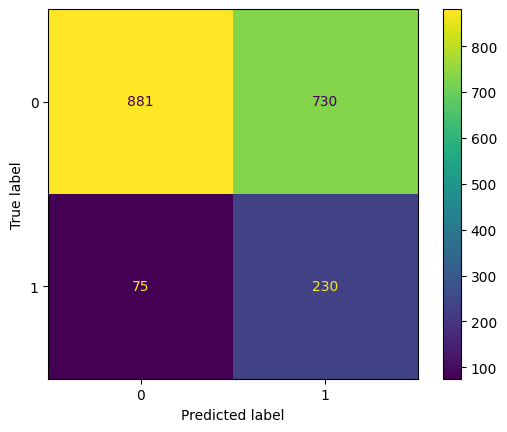

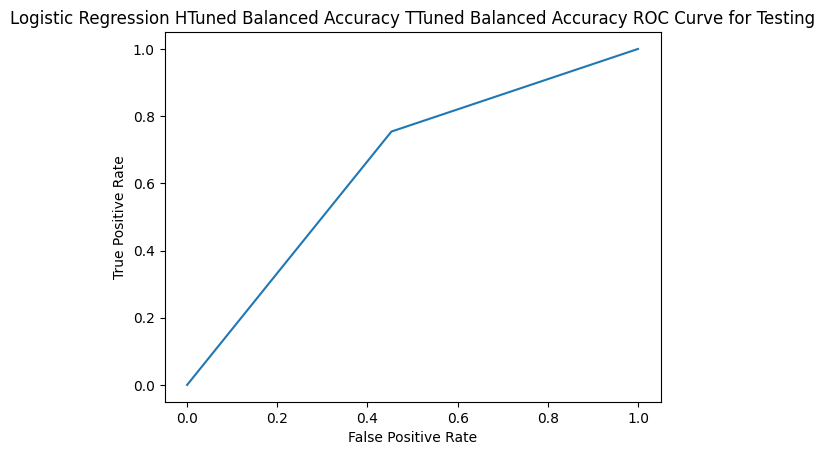

In [ ]:
viewTestResults(name, logRegHbaccTbacc, hMetric, tMetric)

## Linear SVC

In [ ]:
name = 'Linear SVC'

In [ ]:
def probDistTrainLinSVC(name, model):
  probTrain = model.decision_function(Xtrain)
  sns.histplot(x = probTrain, hue = ytrain, kde = True)
  plt.xlabel('Distance from Decision Bounday')
  plt.title(f'Probability Distribution Chart for {name} Training Set')
  plt.show()

In [ ]:
def probDistTestLinSVC(name, model):
  probTest = model.decision_function(Xtest)
  sns.histplot(x = probTest, hue = ytest, kde = True)
  plt.xlabel('Distance from Decision Boundary')
  plt.title(f'Probability Distribution Chart for {name} Testing Set')
  plt.show()

### No Tuning

Classification report for Linear SVC training set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      6434
           1       0.33      0.00      0.00      1228

    accuracy                           0.84      7662
   macro avg       0.59      0.50      0.46      7662
weighted avg       0.76      0.84      0.77      7662



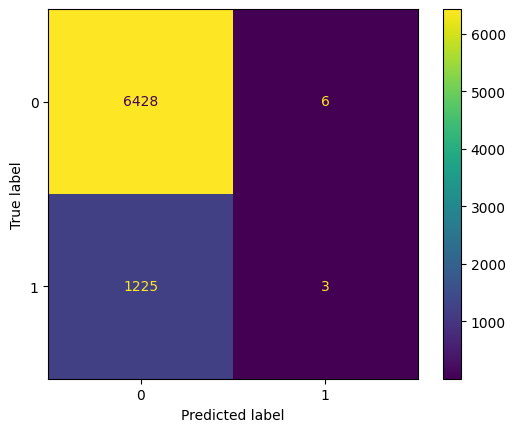

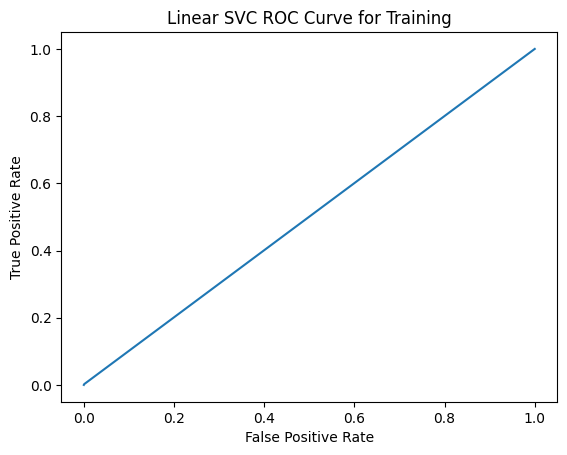

In [ ]:
hMetric = 'No'
tMetric = 'No'

linSVC = LinearSVC()
viewTrainResults(name, linSVC, hMetric, tMetric)

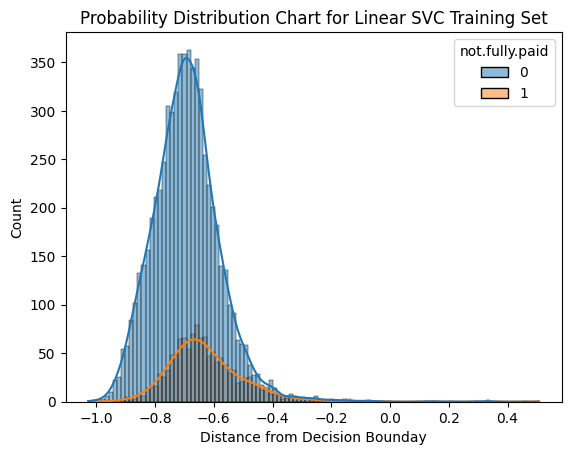

In [ ]:
probDistTrainLinSVC(name, linSVC)

Classification report for Linear SVC testing set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.67      0.01      0.01       305

    accuracy                           0.84      1916
   macro avg       0.75      0.50      0.46      1916
weighted avg       0.81      0.84      0.77      1916



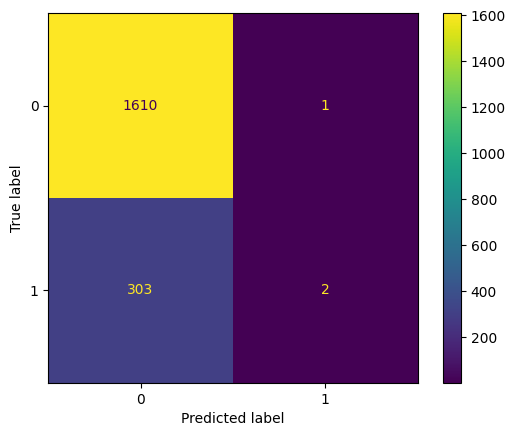

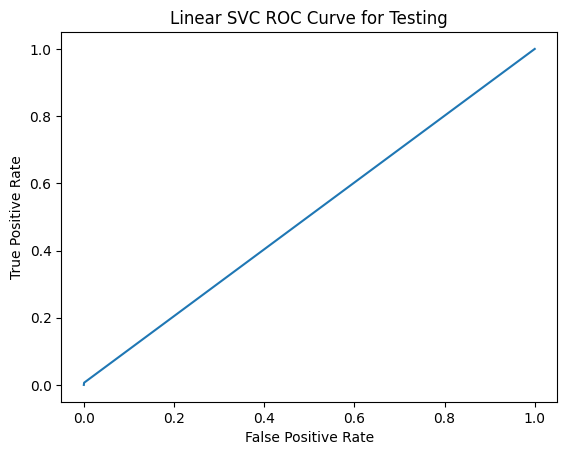

In [ ]:
viewTestResults(name, linSVC, hMetric, tMetric)

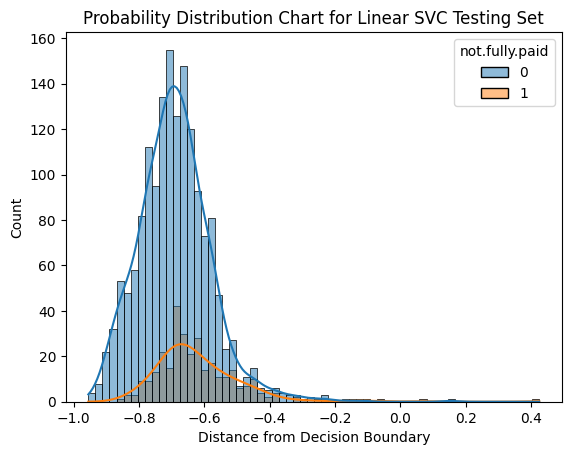

In [ ]:
probDistTestLinSVC(name, linSVC)

### With Hyperparameter Tuning

In [ ]:
linSVCParams = {'penalty': ['l1', 'l2'],
                'loss': ['hinge', 'squared_hinge'],
                'tol': [.0005, .001, 1],
                'C': [.0005, .001, 1, 5, 100] }

hMetric = 'Balanced Accuracy'

Classification report for Linear SVC HTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.89      0.66      0.76      6434
           1       0.24      0.57      0.34      1228

    accuracy                           0.65      7662
   macro avg       0.57      0.62      0.55      7662
weighted avg       0.79      0.65      0.69      7662



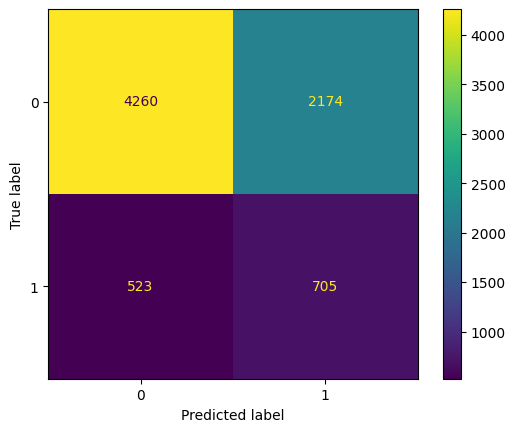

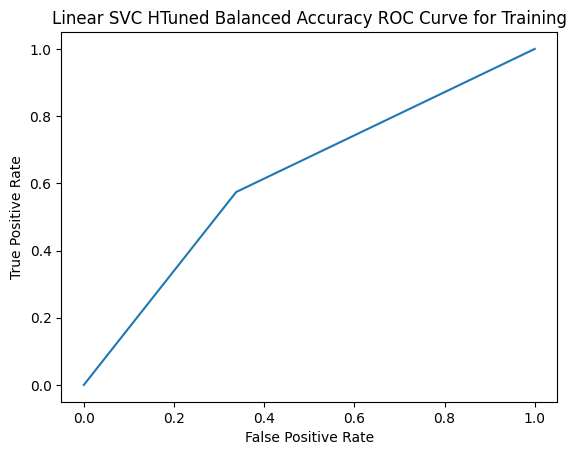

In [ ]:
if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  linSVCHbacc = GridSearchCV(LinearSVC(class_weight = 'balanced'), param_grid = linSVCParams, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  linSVCHbacc = GridSearchCV(LinearSVC(class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')

viewTrainResults(name, linSVCHbacc, hMetric, tMetric)

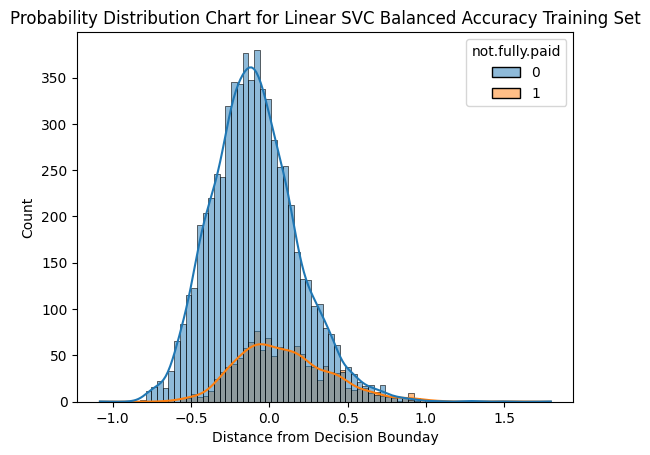

In [ ]:
probDistTrainLinSVC(f'{name} {hMetric}', linSVCHbacc)

Classification report for Linear SVC HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1611
           1       0.27      0.65      0.38       305

    accuracy                           0.66      1916
   macro avg       0.59      0.66      0.57      1916
weighted avg       0.81      0.66      0.71      1916



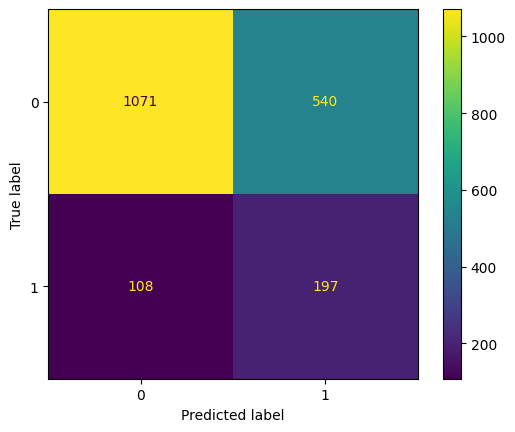

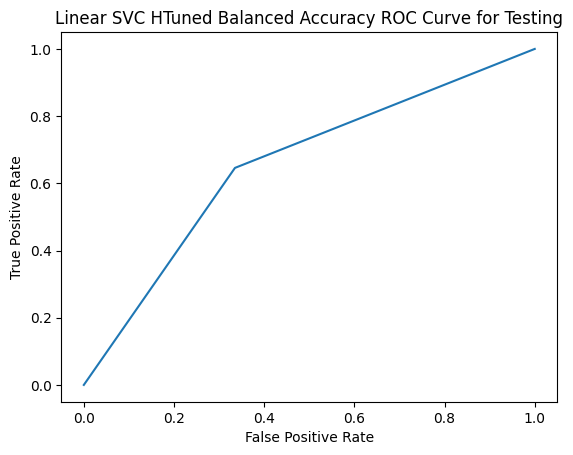

In [ ]:
viewTestResults(name, linSVCHbacc, hMetric, tMetric)

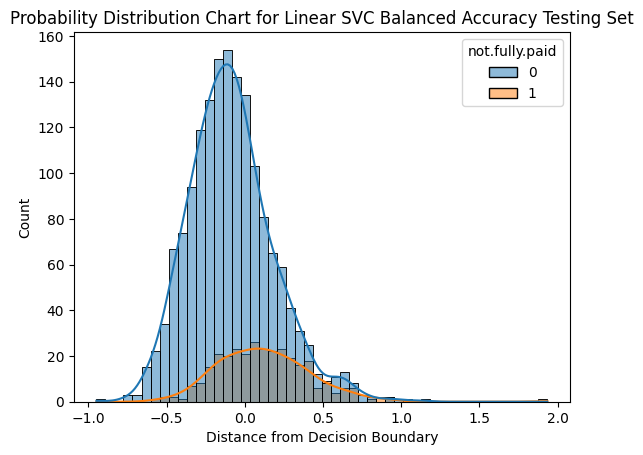

In [ ]:
probDistTestLinSVC(f'{name} {hMetric}', linSVCHbacc)

### With Threshold Tuning

Classification report for Linear SVC HTuned Balanced Accuracy TTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.91      0.53      0.67      6434
           1       0.22      0.71      0.34      1228

    accuracy                           0.56      7662
   macro avg       0.56      0.62      0.50      7662
weighted avg       0.80      0.56      0.61      7662



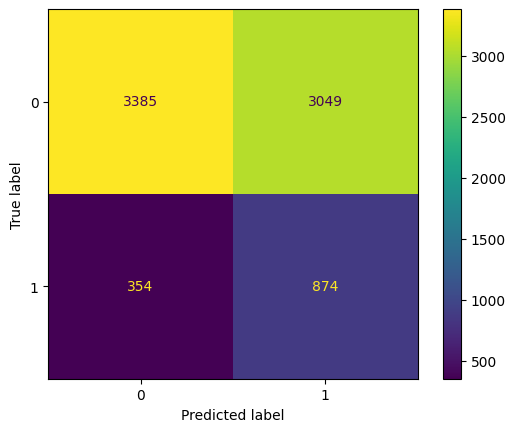

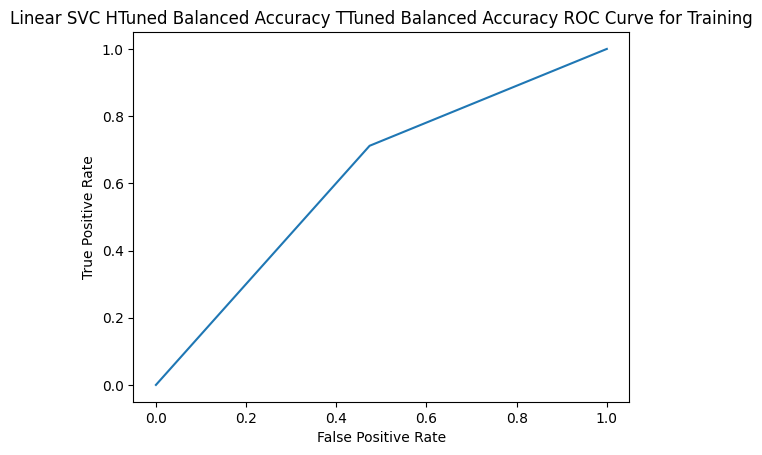

In [ ]:
tMetric = 'Balanced Accuracy'

linSVCHbaccTbacc = TunedThresholdClassifierCV(linSVCHbacc.best_estimator_, cv = 5, scoring = 'balanced_accuracy')
viewTrainResults(name, linSVCHbaccTbacc, hMetric, tMetric)

Classification report for Linear SVC HTuned Balanced Accuracy TTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.92      0.52      0.66      1611
           1       0.23      0.75      0.35       305

    accuracy                           0.56      1916
   macro avg       0.57      0.64      0.51      1916
weighted avg       0.81      0.56      0.61      1916



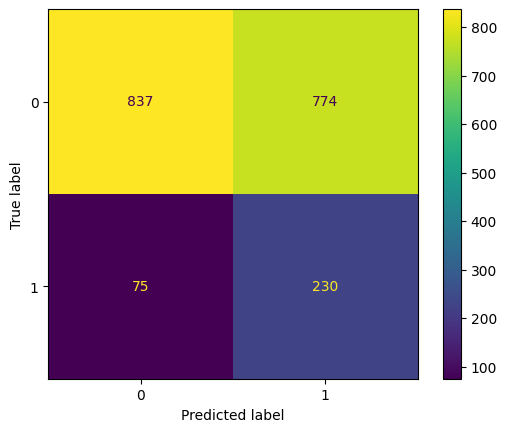

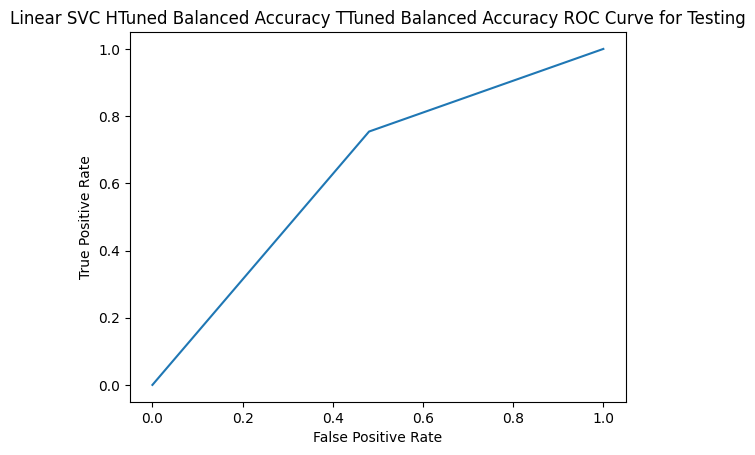

In [ ]:
viewTestResults(name, linSVCHbaccTbacc, hMetric, tMetric)

## Native Bayes

In [ ]:
name = 'Native Bayes'

Classification report for Native Bayes training set 
 
               precision    recall  f1-score   support

           0       0.85      0.96      0.90      6434
           1       0.32      0.10      0.15      1228

    accuracy                           0.82      7662
   macro avg       0.59      0.53      0.53      7662
weighted avg       0.76      0.82      0.78      7662



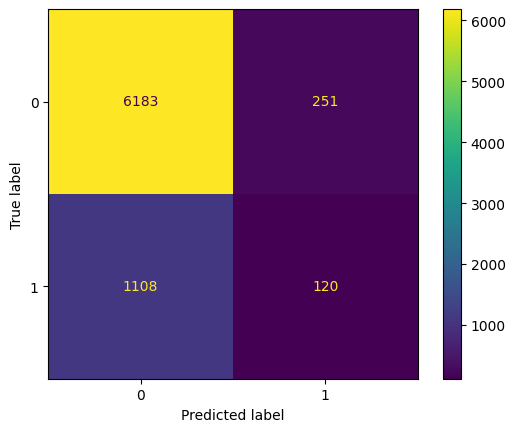

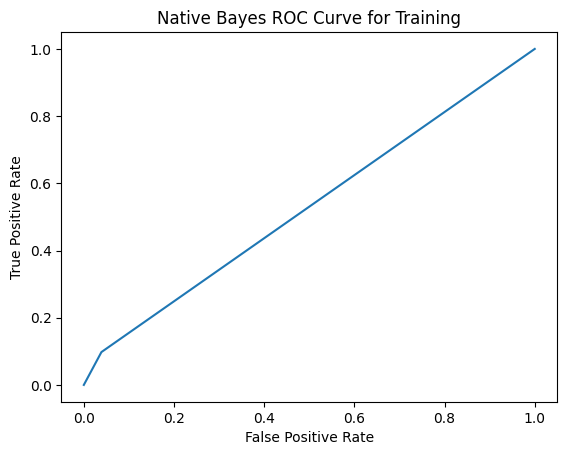

In [ ]:
hMetric = 'No'
tMetric = 'No'
nb = GaussianNB()
viewTrainResults(name, nb, hMetric, tMetric)

Classification report for Native Bayes testing set 
 
               precision    recall  f1-score   support

           0       0.85      0.96      0.90      1611
           1       0.29      0.09      0.14       305

    accuracy                           0.82      1916
   macro avg       0.57      0.52      0.52      1916
weighted avg       0.76      0.82      0.78      1916



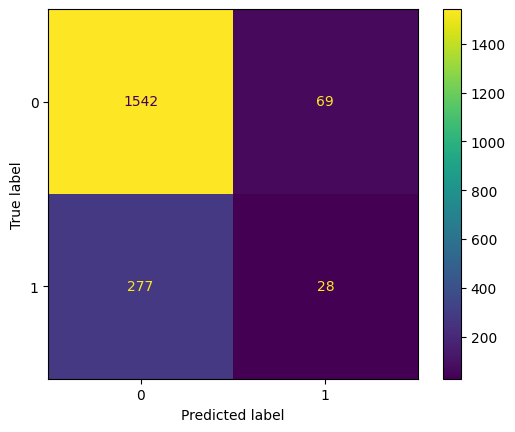

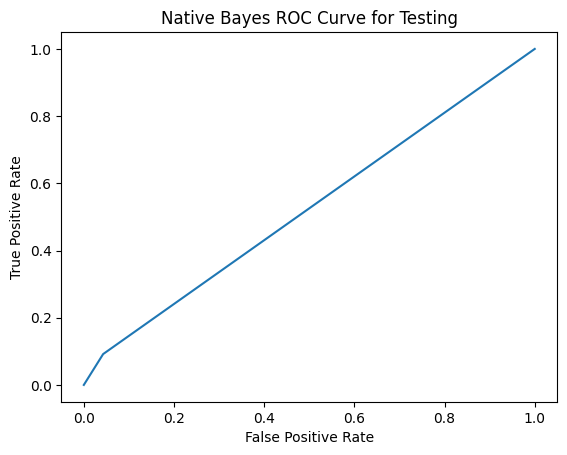

In [ ]:
viewTestResults(name, nb, hMetric, tMetric)

## KNN

In [ ]:
name = 'KNN'

### No Tuning

Classification report for KNN training set 
 
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      6434
           1       0.61      0.14      0.22      1228

    accuracy                           0.85      7662
   macro avg       0.73      0.56      0.57      7662
weighted avg       0.82      0.85      0.80      7662



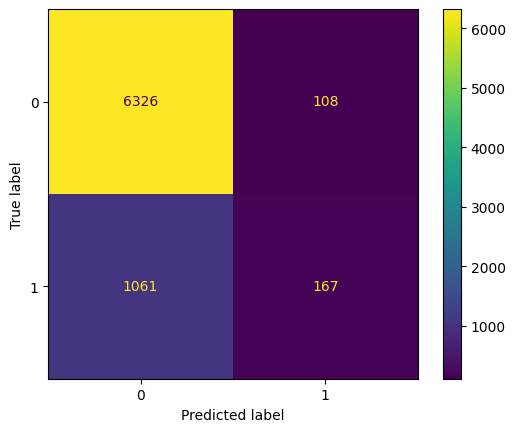

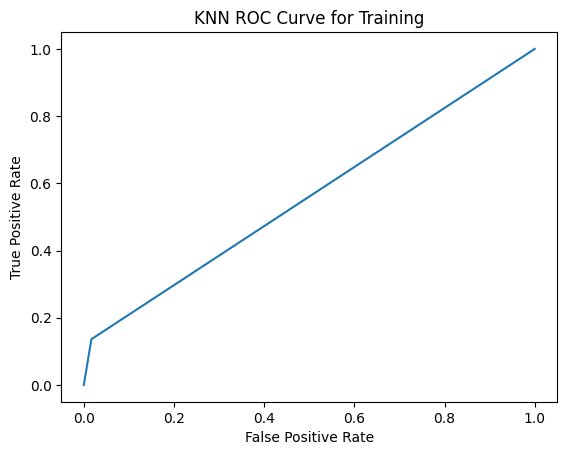

In [ ]:
hMetric = 'No'
tMetric = 'No'

knn = KNeighborsClassifier()
viewTrainResults(name, knn, hMetric, tMetric)

Classification report for KNN testing set 
 
               precision    recall  f1-score   support

           0       0.84      0.96      0.90      1611
           1       0.18      0.05      0.08       305

    accuracy                           0.81      1916
   macro avg       0.51      0.50      0.49      1916
weighted avg       0.74      0.81      0.77      1916



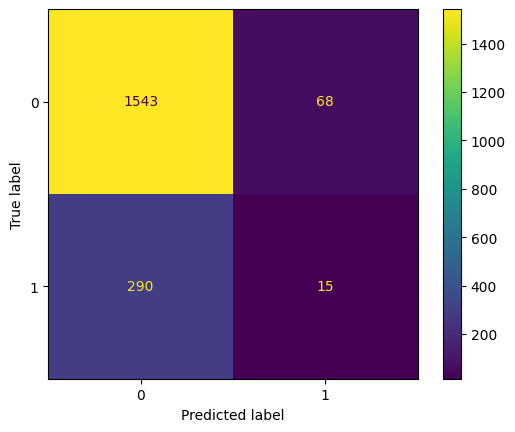

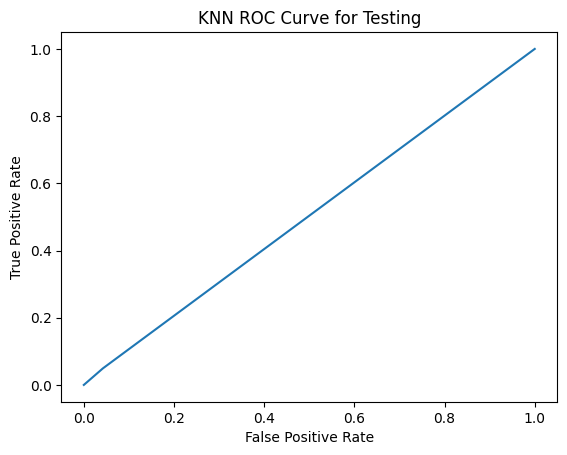

In [ ]:
viewTestResults(name, knn, hMetric, tMetric)

### With Hyperparameter Tuning

In [ ]:
knnHNeighbors = makeStatsDictionary()
neighbors = np.arange(1, 21)

for k in neighbors:
  kTune = KNeighborsClassifier(n_neighbors = k)
  getStats(kTune, knnHNeighbors)

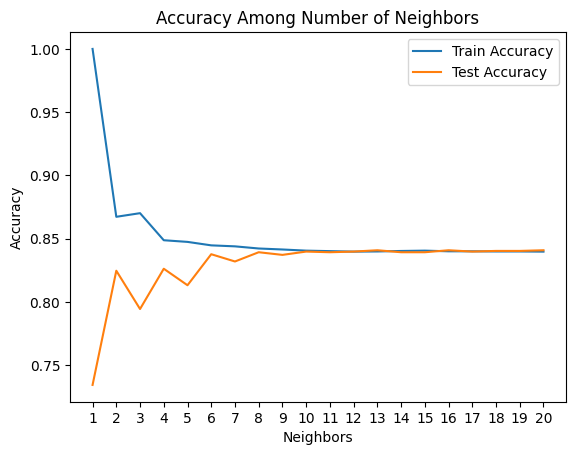

In [ ]:
plotAccs(neighbors, knnHNeighbors, "Accuracy Among Number of Neighbors", "Neighbors", True)

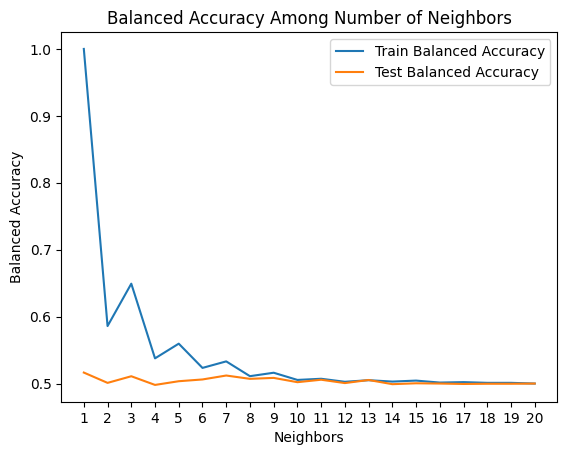

In [ ]:
plotAccs(neighbors, knnHNeighbors, "Balanced Accuracy Among Number of Neighbors", "Neighbors", False)

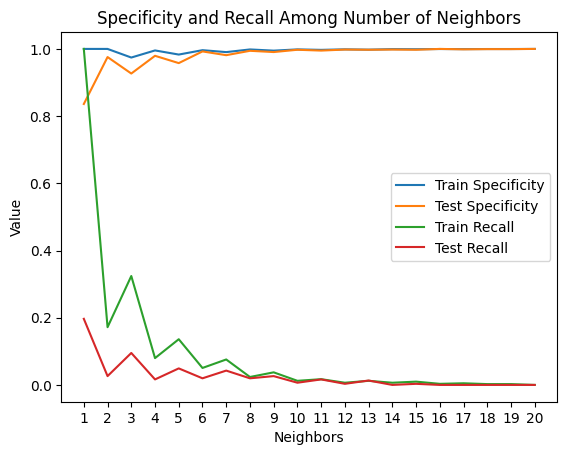

In [ ]:
plotSpecRec(neighbors, knnHNeighbors, "Specificity and Recall Among Number of Neighbors", "Neighbors")

In [ ]:
knnGrid = {'n_neighbors': np.arange(2, 11),
           'algorithm': ['auto', 'ball_tree'],
           'p': np.arange(1, 5)}

Classification report for KNN HTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.86      0.98      0.91      6434
           1       0.59      0.13      0.21      1228

    accuracy                           0.85      7662
   macro avg       0.72      0.56      0.56      7662
weighted avg       0.81      0.85      0.80      7662



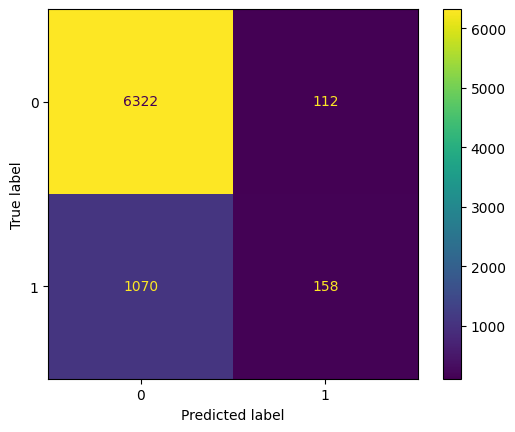

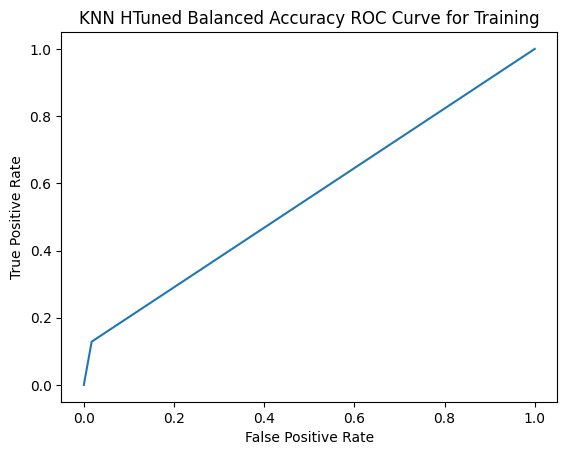

In [ ]:
hMetric = 'Balanced Accuracy'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  knnHbacc = GridSearchCV(KNeighborsClassifier(), param_grid = knnGrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  knnHbacc = GridSearchCV(KNeighborsClassifier(), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')

viewTrainResults(name, knnHbacc, hMetric, tMetric)

Classification report for KNN HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.84      0.96      0.90      1611
           1       0.19      0.06      0.09       305

    accuracy                           0.81      1916
   macro avg       0.52      0.51      0.49      1916
weighted avg       0.74      0.81      0.77      1916



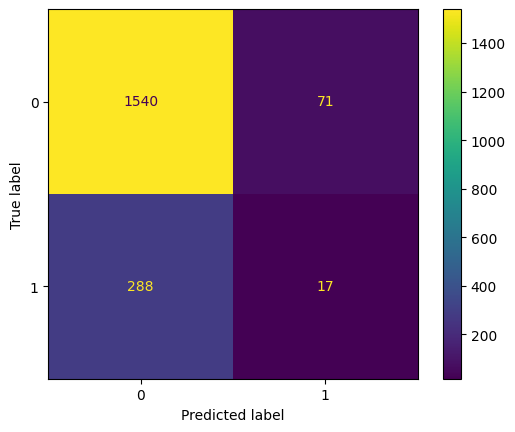

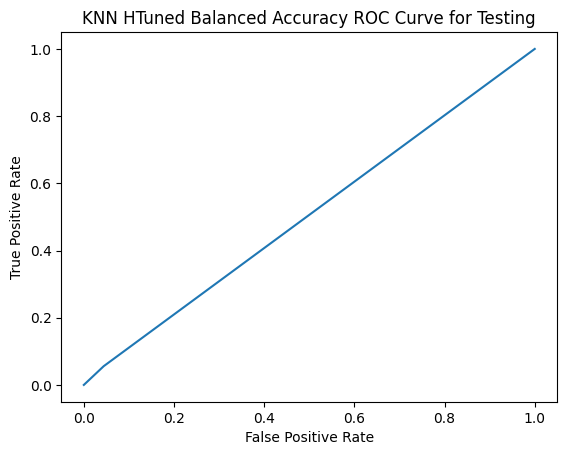

In [ ]:
viewTestResults(name, knnHbacc, hMetric, tMetric)

## Decision Tree

In [ ]:
name = 'Decision Tree'
hMetric = 'No'
tMetric = 'No'


### No Tuning

Classification report for Decision Tree training set 
 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6434
           1       1.00      1.00      1.00      1228

    accuracy                           1.00      7662
   macro avg       1.00      1.00      1.00      7662
weighted avg       1.00      1.00      1.00      7662



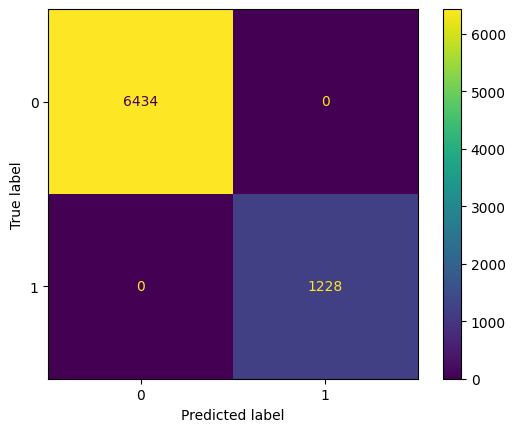

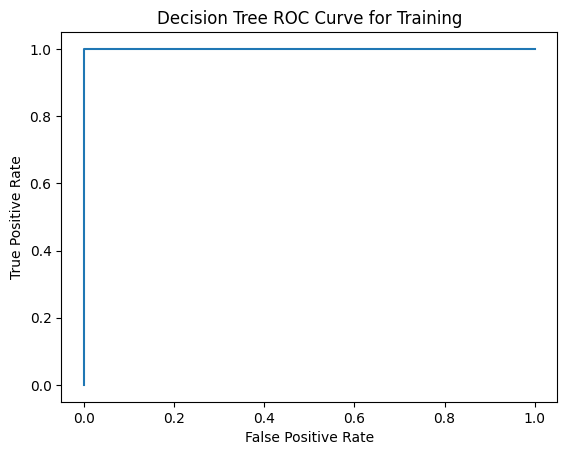

In [ ]:
hMetric = 'No'
tMetric = 'No'

dt = DecisionTreeClassifier()
viewTrainResults(name, dt, hMetric, tMetric)

Classification report for Decision Tree testing set 
 
               precision    recall  f1-score   support

           0       0.85      0.84      0.84      1611
           1       0.22      0.24      0.23       305

    accuracy                           0.74      1916
   macro avg       0.53      0.54      0.54      1916
weighted avg       0.75      0.74      0.75      1916



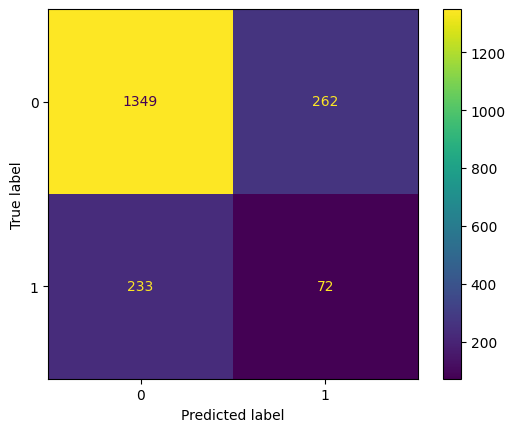

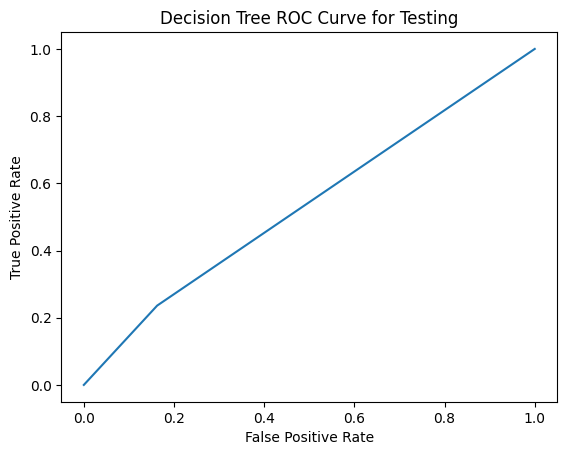

In [ ]:
viewTestResults(name, dt, hMetric, tMetric)

### With Hyperparamter Tuning

In [ ]:
depth = np.arange(2, 50)
dtHDepth = makeStatsDictionary()

for dh in depth:
  DTmd = DecisionTreeClassifier(random_state = 42, class_weight = "balanced", max_depth = dh)
  getStats(DTmd, dtHDepth)

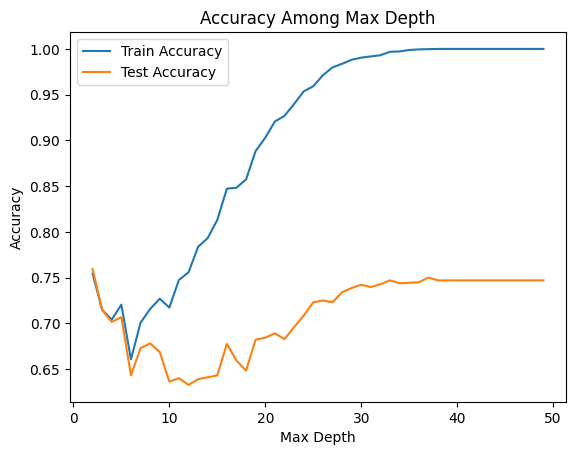

In [ ]:
plotAccs(depth, dtHDepth, "Accuracy Among Max Depth", "Max Depth", True)

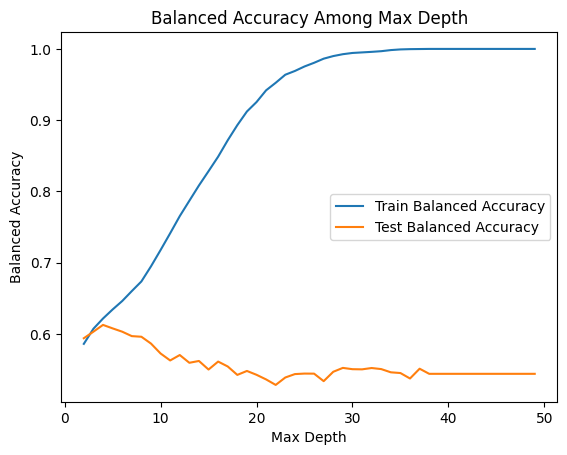

In [ ]:
plotAccs(depth, dtHDepth, "Balanced Accuracy Among Max Depth", "Max Depth", False)

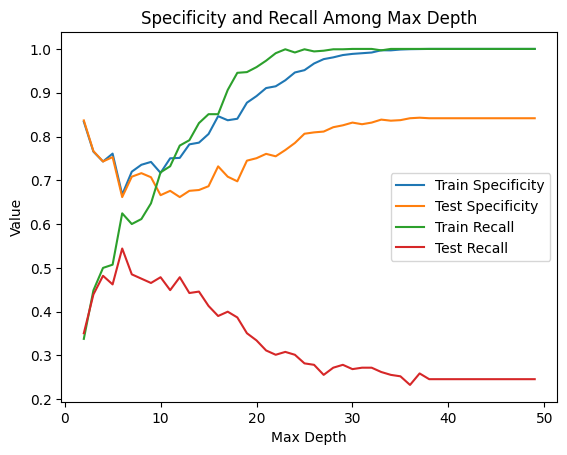

In [ ]:
plotSpecRec(depth, dtHDepth, "Specificity and Recall Among Max Depth", "Max Depth")

In [ ]:
sample_split = np.arange(2, 300)
dtHss = makeStatsDictionary()

for ss in sample_split:
  DTmd = DecisionTreeClassifier(random_state = 42, class_weight = "balanced", min_samples_split = ss)
  getStats(DTmd, dtHss)

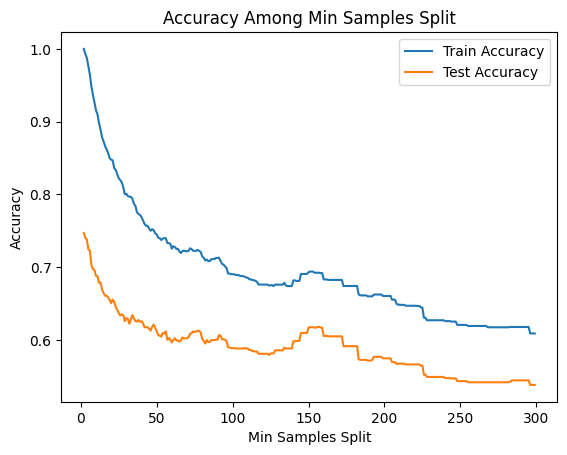

In [ ]:
plotAccs(sample_split, dtHss, "Accuracy Among Min Samples Split", "Min Samples Split", True)

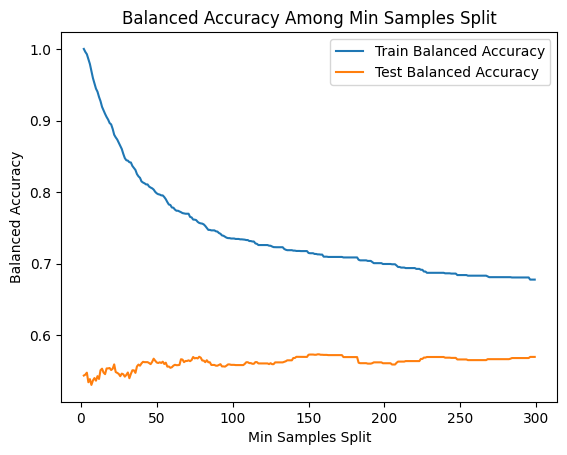

In [ ]:
plotAccs(sample_split, dtHss, "Balanced Accuracy Among Min Samples Split", "Min Samples Split", False)

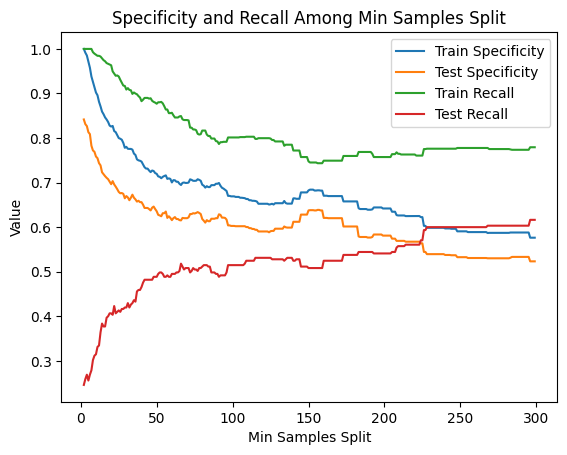

In [ ]:
plotSpecRec(sample_split, dtHss, "Specificity and Recall Among Min Samples Split", "Min Samples Split")

In [ ]:
leaf_samples = np.arange(2, 300)
dtHls = makeStatsDictionary()

for ls in leaf_samples:
  DTmd = DecisionTreeClassifier(random_state = 42, class_weight = "balanced", min_samples_leaf = ls)
  getStats(DTmd, dtHls)

KeyboardInterrupt: 

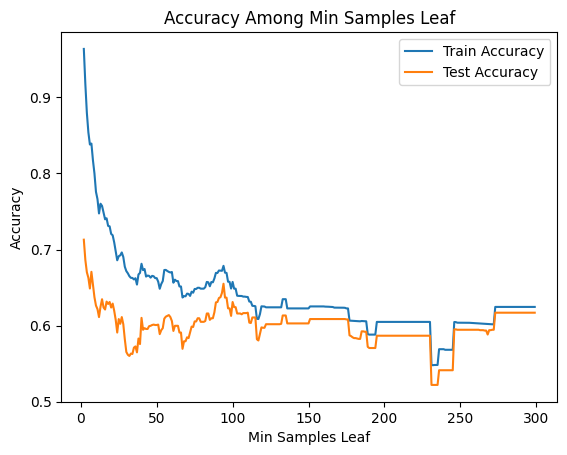

In [ ]:
plotAccs(leaf_samples, dtHls, "Accuracy Among Min Samples Leaf", "Min Samples Leaf", True)

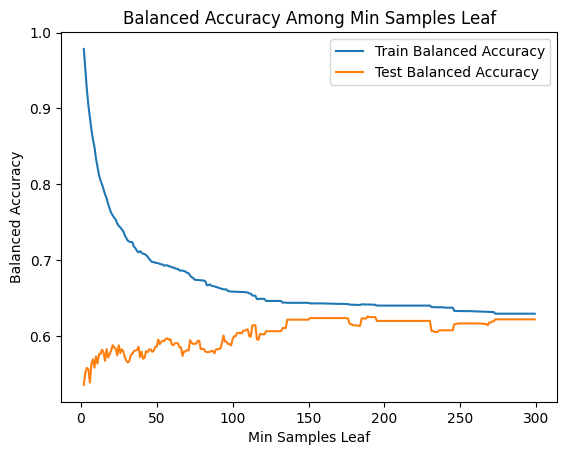

In [ ]:
plotAccs(leaf_samples, dtHls, "Balanced Accuracy Among Min Samples Leaf", "Min Samples Leaf", False)

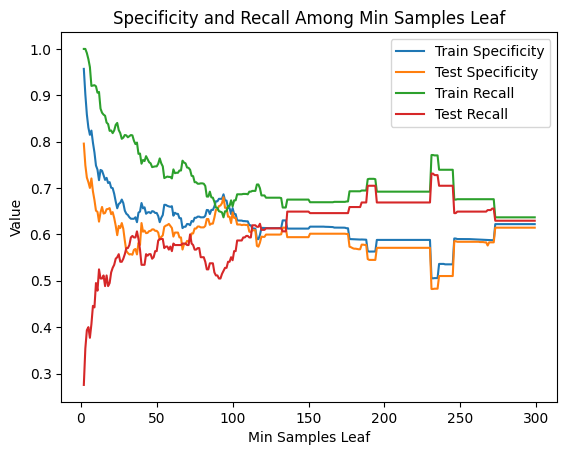

In [ ]:
plotSpecRec(leaf_samples, dtHls, "Specificity and Recall Among Min Samples Leaf", "Min Samples Leaf")

In [ ]:
max_features = np.arange(1, 20)
dtHmf = makeStatsDictionary()

for mf in max_features:
  DTmd = DecisionTreeClassifier(random_state = 42, class_weight = "balanced", max_features = mf, max_depth = 20)
  getStats(DTmd, dtHmf)

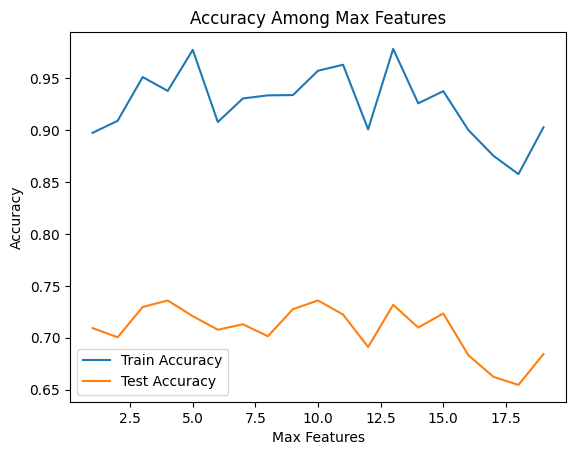

In [ ]:
plotAccs(max_features, dtHmf, "Accuracy Among Max Features", "Max Features", True)

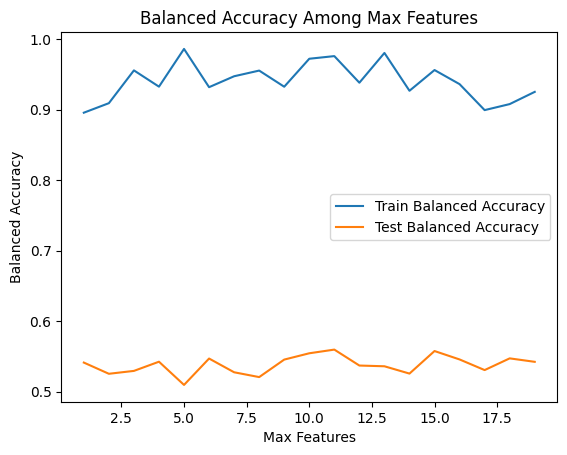

In [ ]:
plotAccs(max_features, dtHmf, "Balanced Accuracy Among Max Features", "Max Features", False)

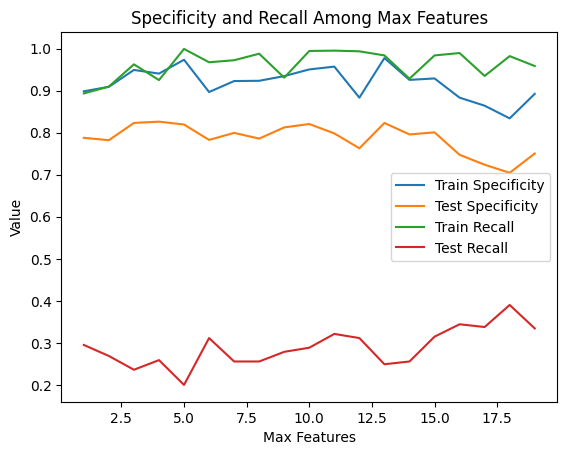

In [ ]:
plotSpecRec(max_features, dtHmf, "Specificity and Recall Among Max Features", "Max Features")

In [ ]:
dtGrid = {'criterion': ['gini', 'entropy', 'log_loss'],
          'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 16],
          'min_samples_split': [50, 150, 300],
          'min_samples_leaf': [50, 150, 300],
          'max_features': ['sqrt', 'log2', None, 12]}

Classification report for Decision Tree HTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.88      0.76      0.82      6434
           1       0.27      0.47      0.35      1228

    accuracy                           0.71      7662
   macro avg       0.58      0.62      0.58      7662
weighted avg       0.79      0.71      0.74      7662



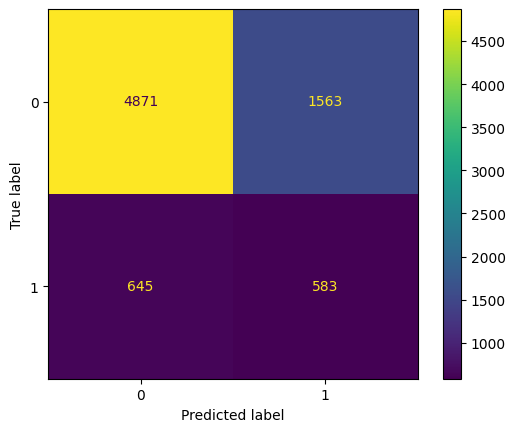

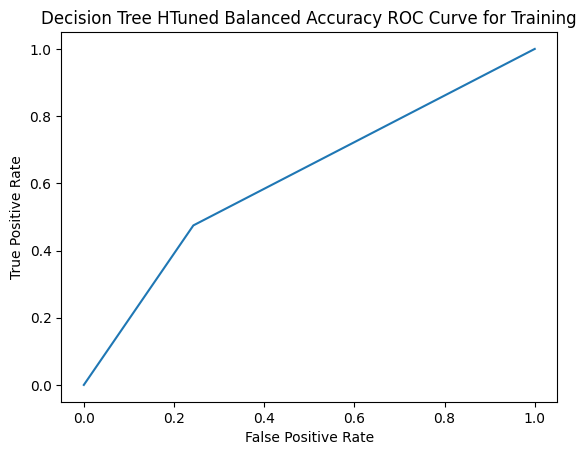

In [ ]:
hMetric = 'Balanced Accuracy'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  dtHbacc = GridSearchCV(DecisionTreeClassifier(random_state = 42, class_weight = 'balanced'), param_grid = dtGrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  dtHbacc = GridSearchCV(DecisionTreeClassifier(random_state = 42, class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')

viewTrainResults(name, dtHbacc, hMetric, tMetric)

Classification report for Decision Tree HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.88      0.76      0.82      1611
           1       0.27      0.47      0.35       305

    accuracy                           0.72      1916
   macro avg       0.58      0.62      0.58      1916
weighted avg       0.79      0.72      0.74      1916



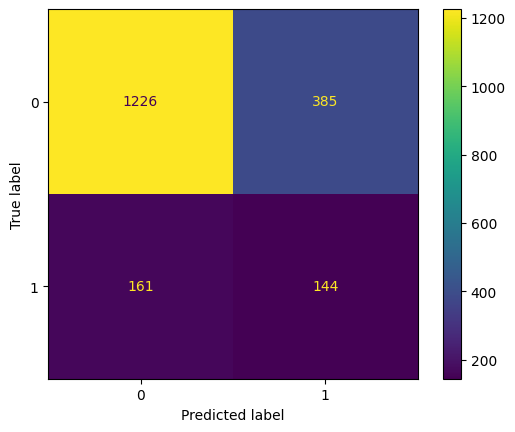

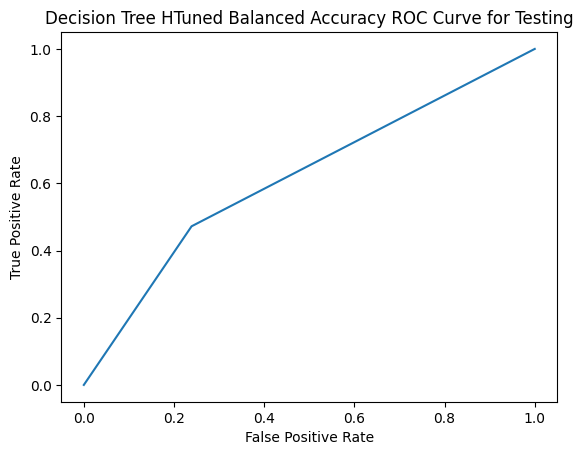

In [ ]:
viewTestResults(name, dtHbacc, hMetric, tMetric)

## Random Forest

In [21]:
name = 'Random Forest'


### No Tuning

Classification report for Random Forest training set 
 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6434
           1       1.00      1.00      1.00      1228

    accuracy                           1.00      7662
   macro avg       1.00      1.00      1.00      7662
weighted avg       1.00      1.00      1.00      7662



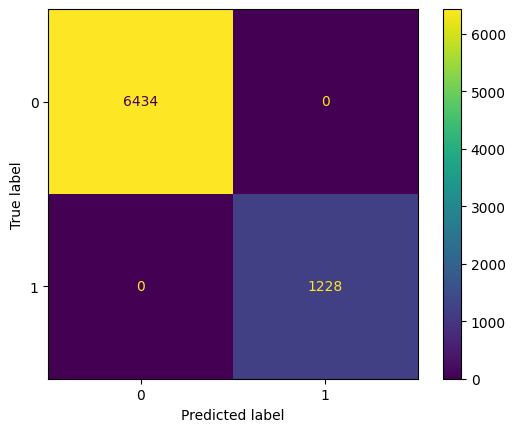

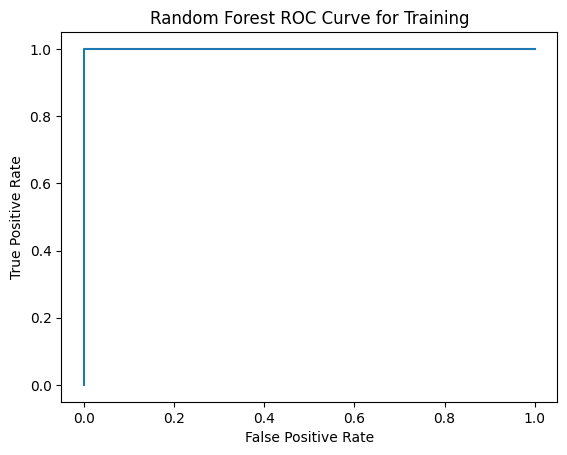

In [22]:
hMetric = 'No'
tMetric = 'No'

rf = RandomForestClassifier()
viewTrainResults(name, rf, hMetric, tMetric)

Classification report for Random Forest testing set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.42      0.02      0.03       305

    accuracy                           0.84      1916
   macro avg       0.63      0.51      0.47      1916
weighted avg       0.77      0.84      0.77      1916



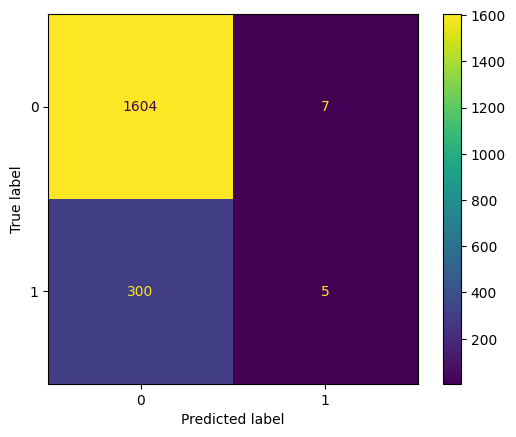

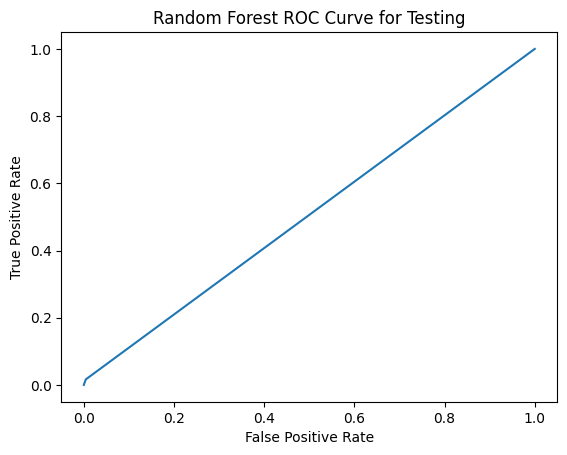

In [23]:
viewTestResults(name, rf, hMetric, tMetric)

### With Hyperparamter Tuning

In [30]:
estimators = np.arange(2, 30)
rfHEst = makeStatsDictionary()

for est in estimators:
  RFmd = RandomForestClassifier(random_state = 42, class_weight = "balanced", n_estimators = est)
  getStats(RFmd, rfHEst)

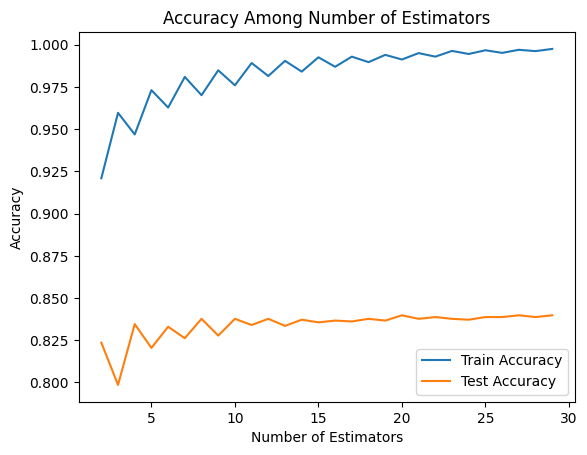

In [31]:
plotAccs(estimators, rfHEst, "Accuracy Among Number of Estimators", "Number of Estimators", True)

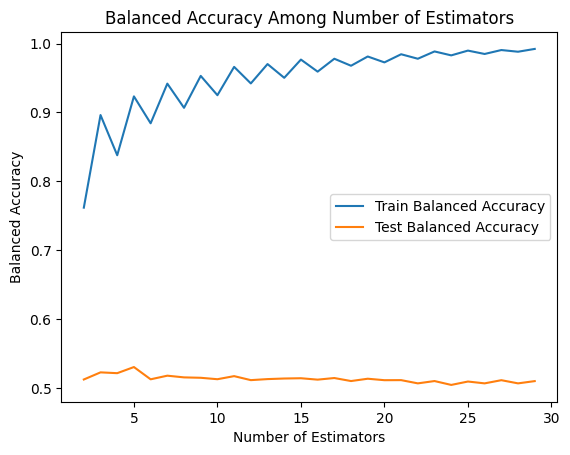

In [32]:
plotAccs(estimators, rfHEst, "Balanced Accuracy Among Number of Estimators", "Number of Estimators", False)

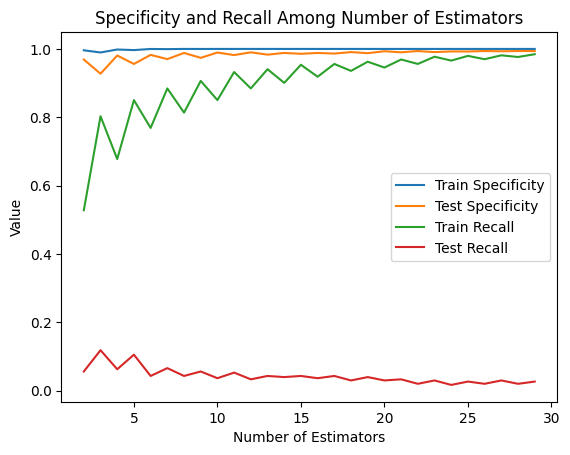

In [33]:
plotSpecRec(estimators, rfHEst, "Specificity and Recall Among Number of Estimators", "Number of Estimators")

In [39]:
depth = np.arange(2, 50)
rfHDepth = makeStatsDictionary()

for dh in depth:
  RFmd = RandomForestClassifier(random_state = 42, class_weight = "balanced", max_depth = dh, n_estimators = 5)
  getStats(RFmd, rfHDepth)

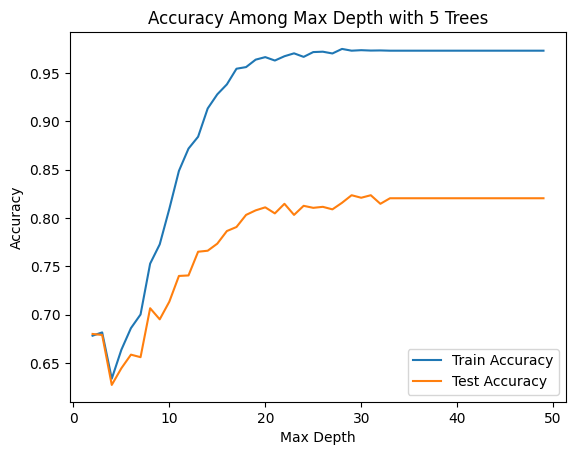

In [41]:
plotAccs(depth, rfHDepth, "Accuracy Among Max Depth with 5 Trees", "Max Depth", True)

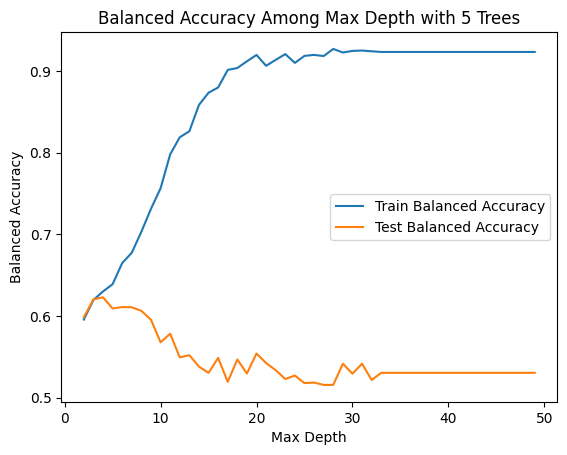

In [42]:
plotAccs(depth, rfHDepth, "Balanced Accuracy Among Max Depth with 5 Trees", "Max Depth", False)

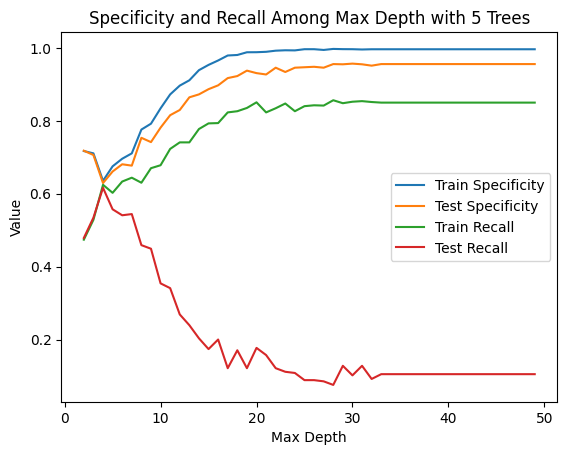

In [43]:
plotSpecRec(depth, rfHDepth, "Specificity and Recall Among Max Depth with 5 Trees", "Max Depth")

In [44]:
sample_split = np.arange(2, 300)
rfHss = makeStatsDictionary()

for ss in sample_split:
  RFmd = RandomForestClassifier(random_state = 42, class_weight = "balanced", min_samples_split = ss, n_estimators = 5)
  getStats(RFmd, rfHss)

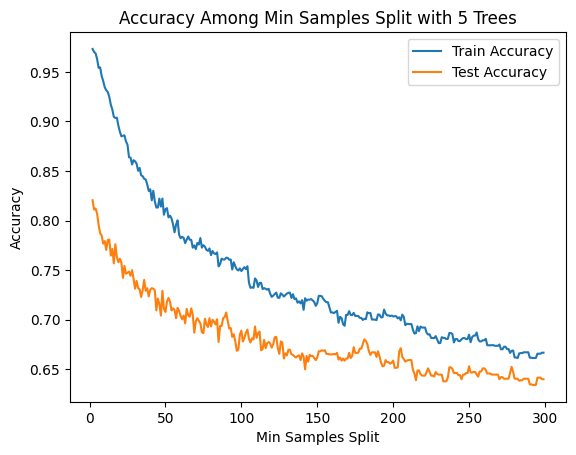

In [47]:
plotAccs(sample_split, rfHss, "Accuracy Among Min Samples Split with 5 Trees", "Min Samples Split", True)

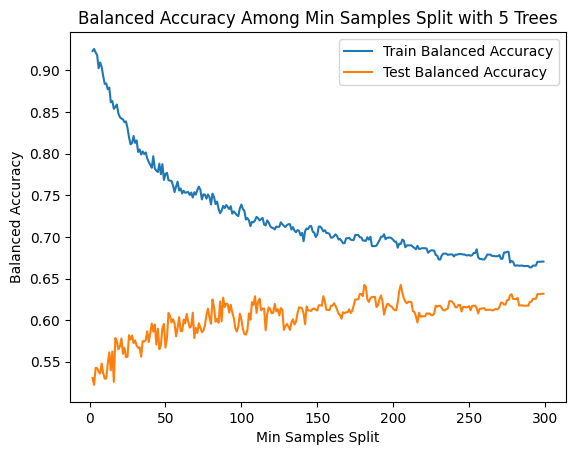

In [48]:
plotAccs(sample_split, rfHss, "Balanced Accuracy Among Min Samples Split with 5 Trees", "Min Samples Split", False)

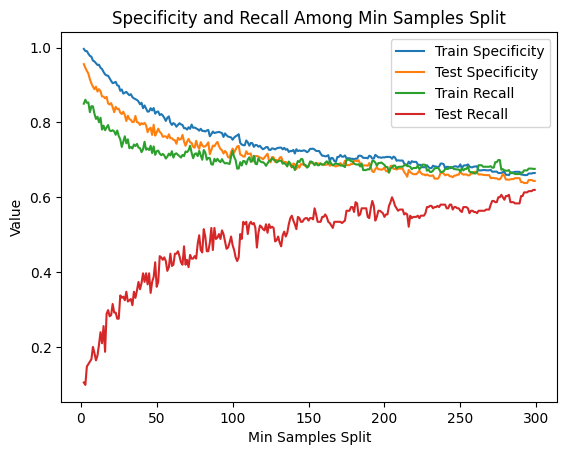

In [50]:
plotSpecRec(sample_split, rfHss, "Specificity and Recall Among Min Samples Split with 5 Trees", "Min Samples Split")

In [51]:
leaf_samples = np.arange(2, 300)
rfHls = makeStatsDictionary()

for ls in leaf_samples:
  RFmd = RandomForestClassifier(random_state = 42, class_weight = "balanced", min_samples_leaf = ls, n_estimators = 5)
  getStats(RFmd, rfHls)

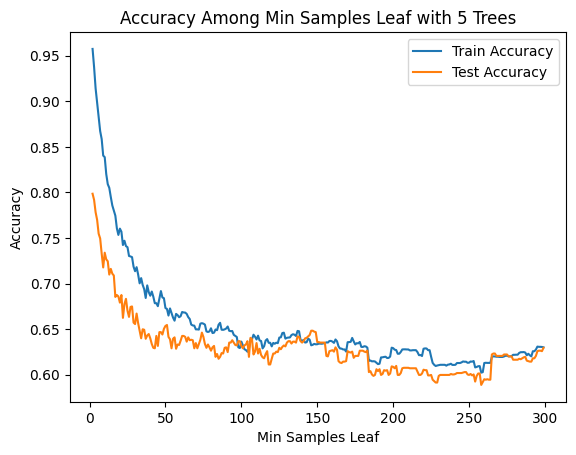

In [54]:
plotAccs(leaf_samples, rfHls, "Accuracy Among Min Samples Leaf with 5 Trees", "Min Samples Leaf", True)

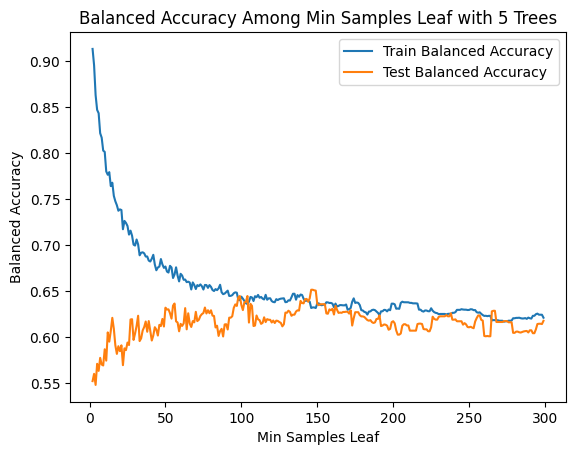

In [55]:
plotAccs(leaf_samples, rfHls, "Balanced Accuracy Among Min Samples Leaf with 5 Trees", "Min Samples Leaf", False)

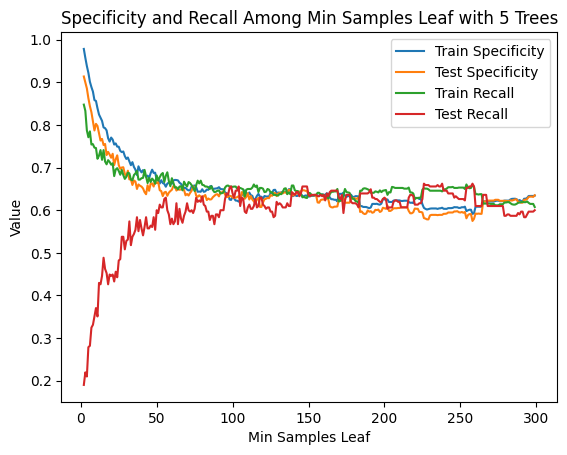

In [56]:
plotSpecRec(leaf_samples, rfHls, "Specificity and Recall Among Min Samples Leaf with 5 Trees", "Min Samples Leaf")

In [57]:
max_features = np.arange(1, 20)
rfHmf = makeStatsDictionary()

for mf in max_features:
  RFmd = RandomForestClassifier(random_state = 42, class_weight = "balanced", max_features = mf, n_estimators = 5)
  getStats(RFmd, rfHmf)

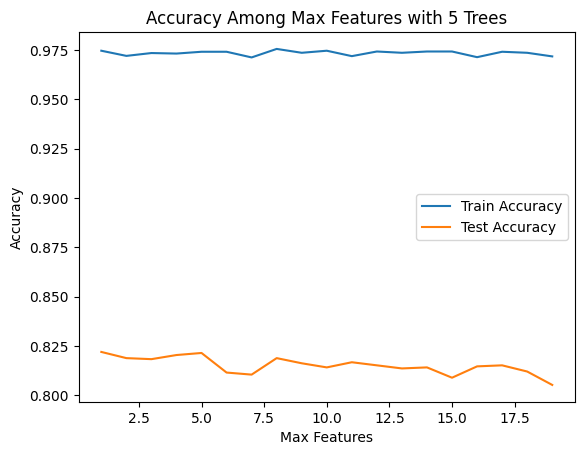

In [58]:
plotAccs(max_features, rfHmf, "Accuracy Among Max Features with 5 Trees", "Max Features", True)

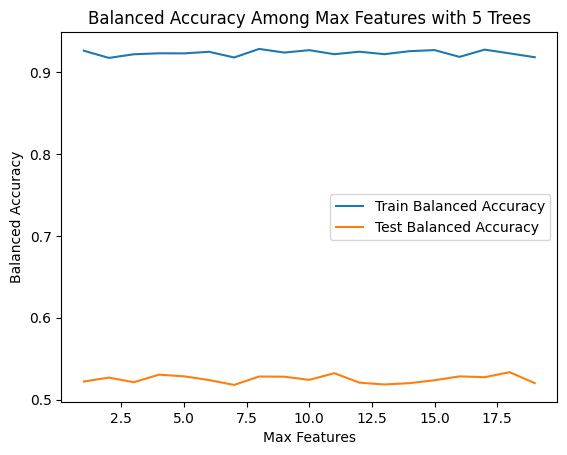

In [59]:
plotAccs(max_features, rfHmf, "Balanced Accuracy Among Max Features with 5 Trees", "Max Features", False)

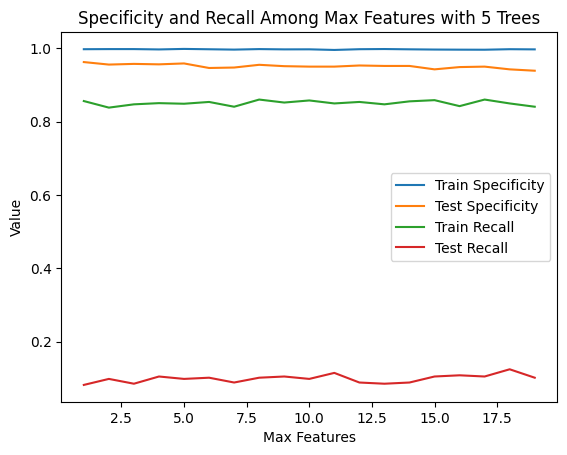

In [60]:
plotSpecRec(max_features, rfHmf, "Specificity and Recall Among Max Features with 5 Trees", "Max Features")

In [23]:
rfGrid = {'criterion': ['gini', 'entropy'],
          'max_depth': [4, 7, 10, 27],
          'min_samples_split': [50, 150, 300],
          'min_samples_leaf': [50, 150, 300],
          'n_estimators': [5, 15, 20]}

Classification report for Random Forest HTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.91      0.63      0.75      6434
           1       0.25      0.66      0.37      1228

    accuracy                           0.64      7662
   macro avg       0.58      0.65      0.56      7662
weighted avg       0.80      0.64      0.69      7662



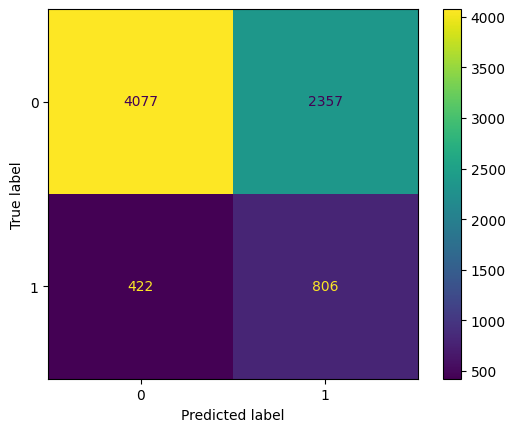

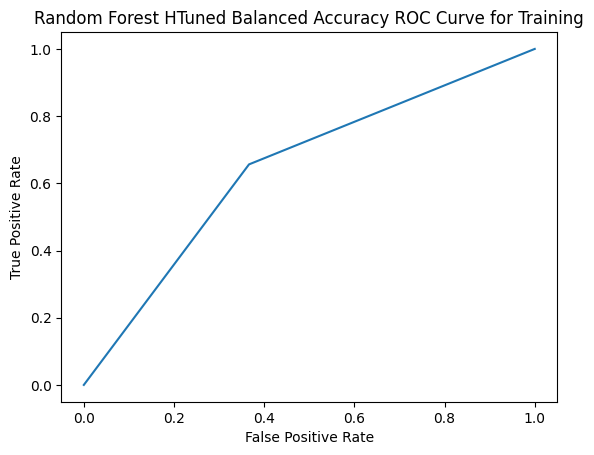

In [24]:
hMetric = 'Balanced Accuracy'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  rfHbacc = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'), param_grid = rfGrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  rfHbacc = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')

viewTrainResults(name, rfHbacc, hMetric, tMetric)

Classification report for Random Forest HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.90      0.62      0.73      1611
           1       0.24      0.64      0.35       305

    accuracy                           0.62      1916
   macro avg       0.57      0.63      0.54      1916
weighted avg       0.79      0.62      0.67      1916



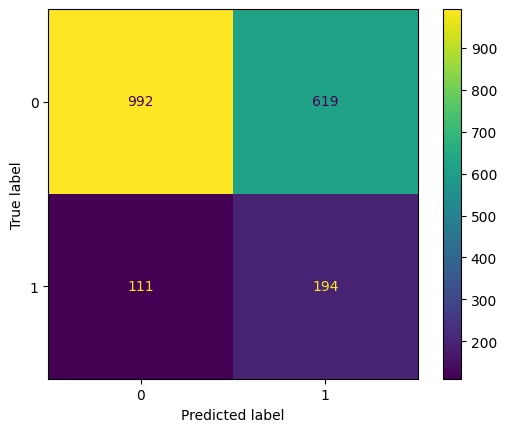

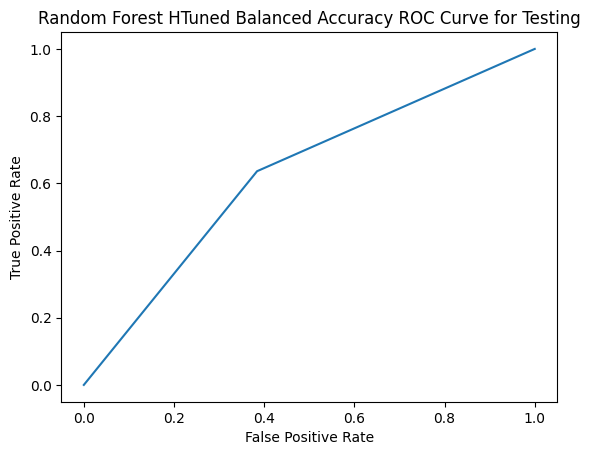

In [25]:
viewTestResults(name, rfHbacc, hMetric, tMetric)

## XGBoost

In [35]:
name = 'XGBoost'


### No Tuning

Classification report for XGBoost training set 
 
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      6434
           1       1.00      0.75      0.86      1228

    accuracy                           0.96      7662
   macro avg       0.98      0.88      0.92      7662
weighted avg       0.96      0.96      0.96      7662



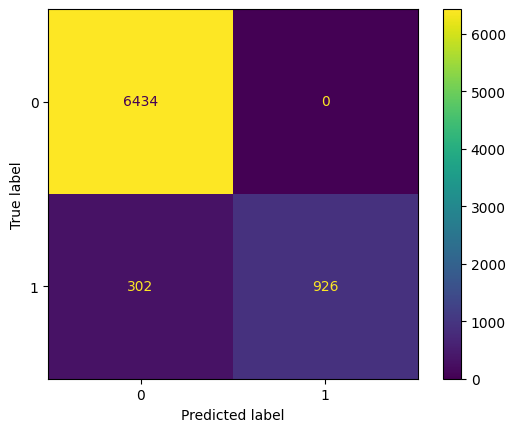

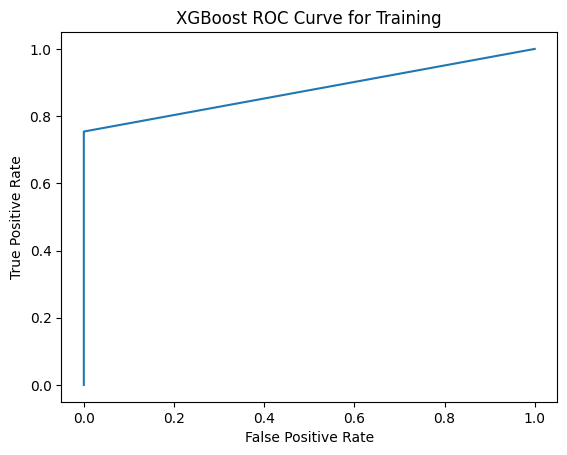

In [36]:
hMetric = 'No'
tMetric = 'No'

xgbooster = xgb.XGBClassifier()
viewTrainResults(name, xgbooster, hMetric, tMetric)

Classification report for XGBoost testing set 
 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90      1611
           1       0.29      0.07      0.12       305

    accuracy                           0.82      1916
   macro avg       0.57      0.52      0.51      1916
weighted avg       0.76      0.82      0.78      1916



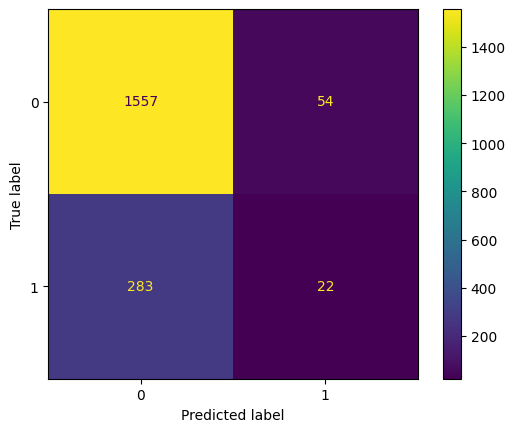

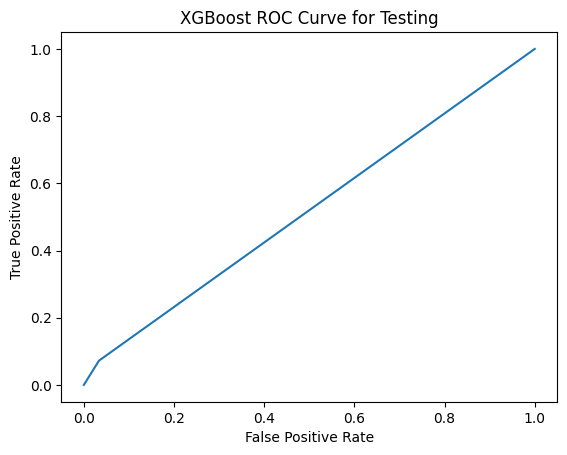

In [37]:
viewTestResults(name, xgbooster, hMetric, tMetric)

### With Hyperparamter Tuning

In [38]:
estimators = np.arange(2, 200, 3)
xgbHEst = makeStatsDictionary()

for est in estimators:
  xgbMd = xgb.XGBClassifier(random_state = 42, class_weight = "balanced", n_estimators = est)
  getStats(xgbMd, xgbHEst)

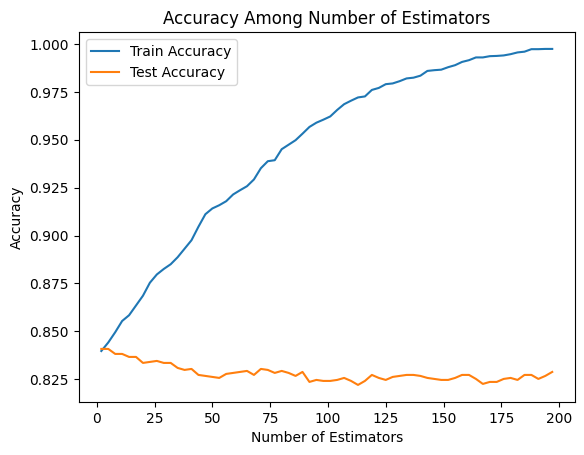

In [39]:
plotAccs(estimators, xgbHEst, "Accuracy Among Number of Estimators", "Number of Estimators", True)

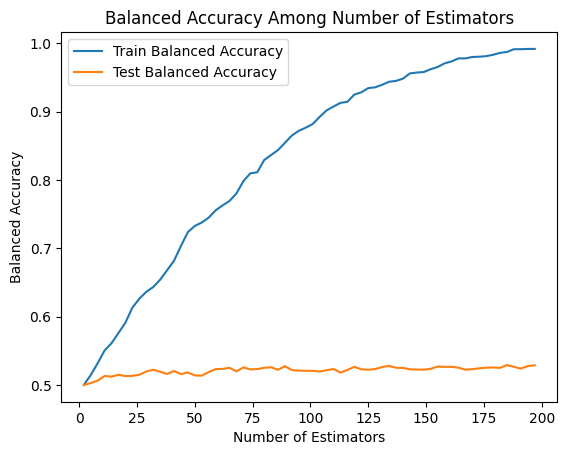

In [40]:
plotAccs(estimators, xgbHEst, "Balanced Accuracy Among Number of Estimators", "Number of Estimators", False)

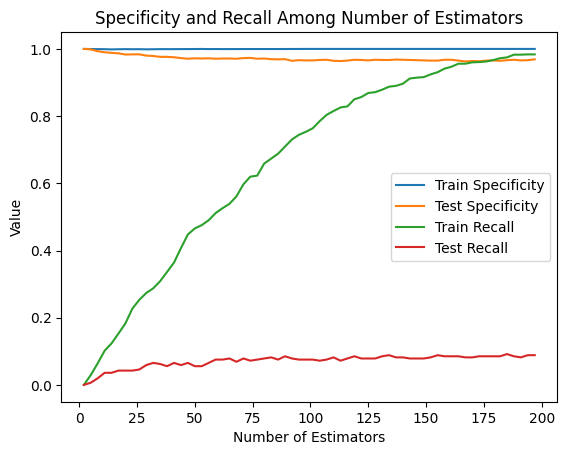

In [41]:
plotSpecRec(estimators, xgbHEst, "Specificity and Recall Among Number of Estimators", "Number of Estimators")

In [46]:
depth = np.arange(2, 200, 5)
xgbHDepth = makeStatsDictionary()

for dh in depth:
  XGBmd = xgb.XGBClassifier(random_state = 42, class_weight = "balanced", max_depth = dh, n_estimators = 5)
  getStats(XGBmd, xgbHDepth)

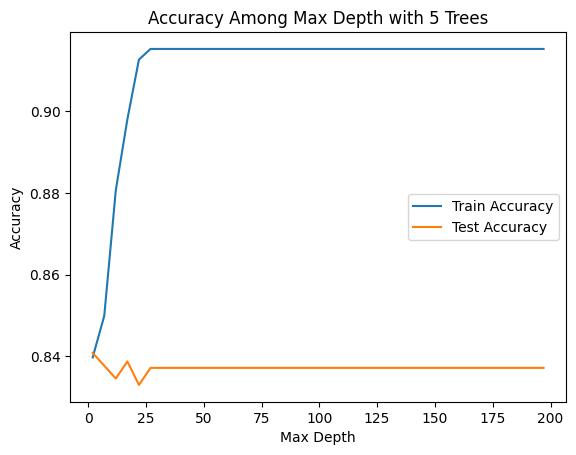

In [47]:
plotAccs(depth, xgbHDepth, "Accuracy Among Max Depth with 5 Trees", "Max Depth", True)

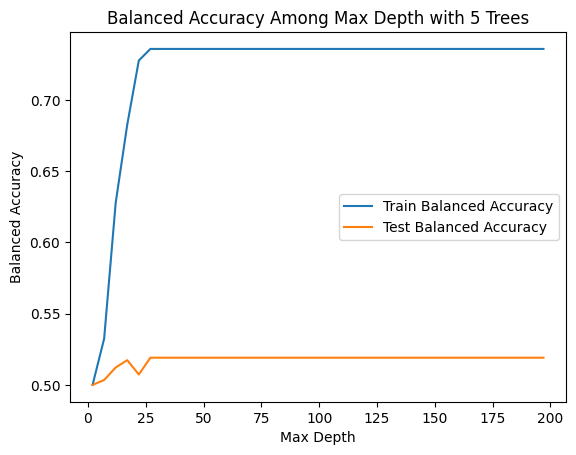

In [49]:
plotAccs(depth, xgbHDepth, "Balanced Accuracy Among Max Depth with 5 Trees", "Max Depth", False)

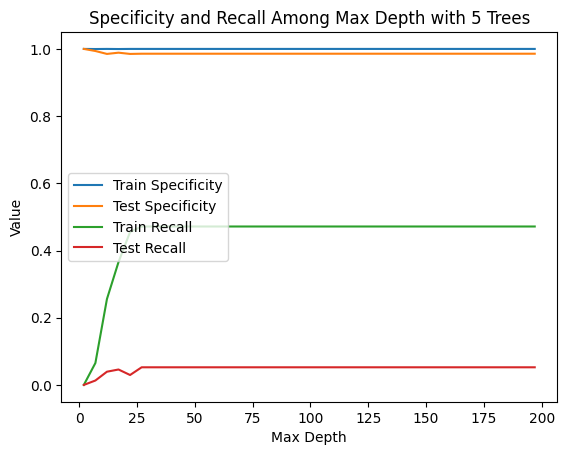

In [50]:
plotSpecRec(depth, xgbHDepth, "Specificity and Recall Among Max Depth with 5 Trees", "Max Depth")

In [61]:
learning_rate = [.001, .005,.01, .05, .1, .15, .25, .4, .5, .6, .75, .95]
xgbHlr = makeStatsDictionary()

for lr in learning_rate:
  XGBmd = xgb.XGBClassifier(random_state = 42, class_weight = "balanced", learning_rate = lr, n_estimators = 5)
  getStats(XGBmd, xgbHlr)

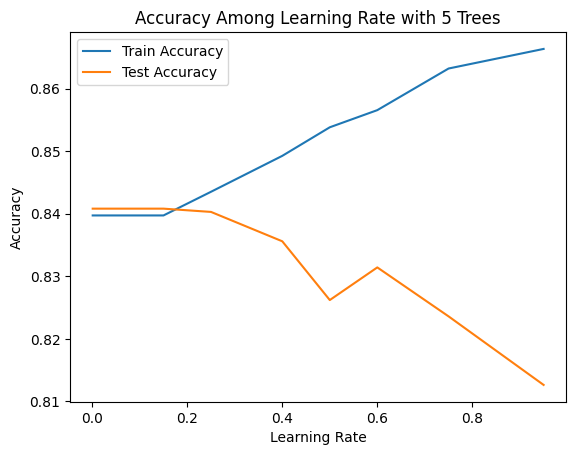

In [62]:
plotAccs(learning_rate, xgbHlr, "Accuracy Among Learning Rate with 5 Trees", "Learning Rate", True)

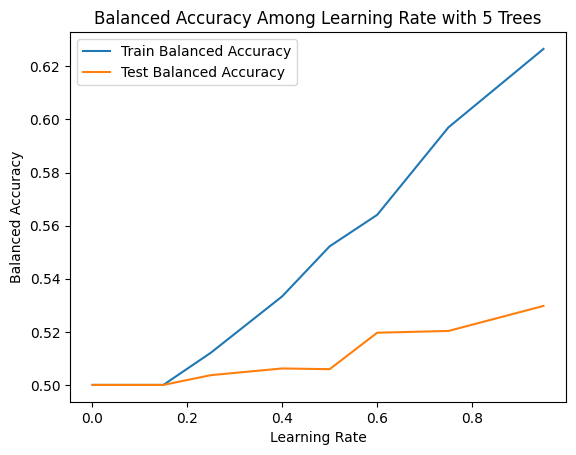

In [63]:
plotAccs(learning_rate, xgbHlr, "Balanced Accuracy Among Learning Rate with 5 Trees", "Learning Rate", False)

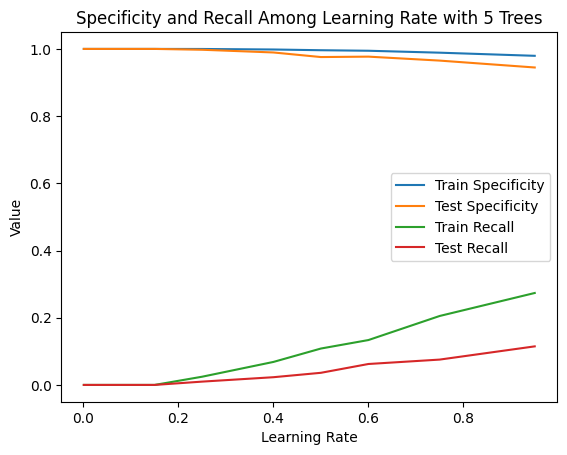

In [64]:
plotSpecRec(learning_rate, xgbHlr, "Specificity and Recall Among Learning Rate with 5 Trees", "Learning Rate")

In [27]:
gamma = [.001, .005,.01, .05, .1, .15, .25, .4, .5, .6, .75, .95]
xgbHg = makeStatsDictionary()

for g in gamma:
  XGBmd = xgb.XGBClassifier(random_state = 42, class_weight = "balanced", gamma = g, n_estimators = 5)
  getStats(XGBmd, xgbHg)

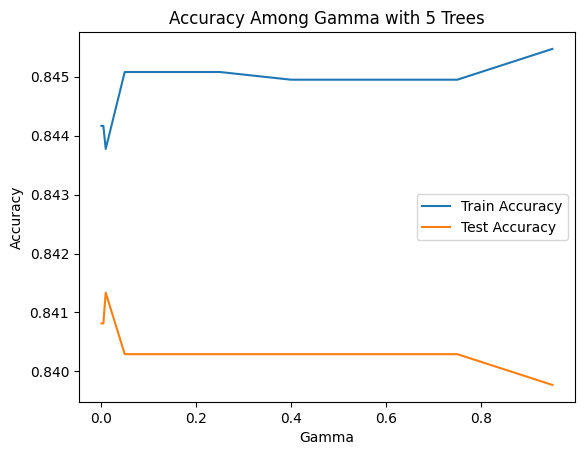

In [29]:
plotAccs(gamma, xgbHg, "Accuracy Among Gamma with 5 Trees", "Gamma", True)

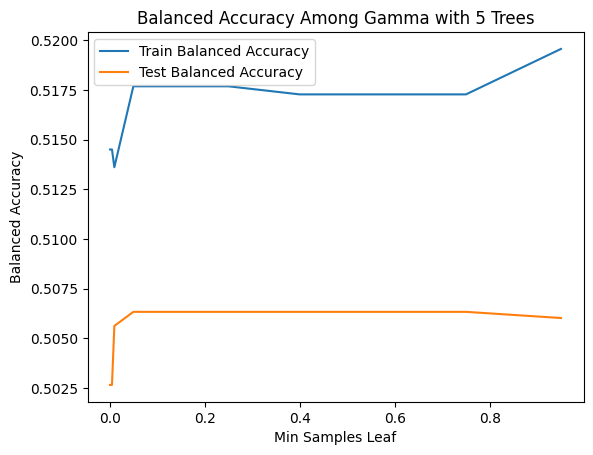

In [31]:
plotAccs(gamma, xgbHg, "Balanced Accuracy Among Gamma with 5 Trees", "Gamma", False)

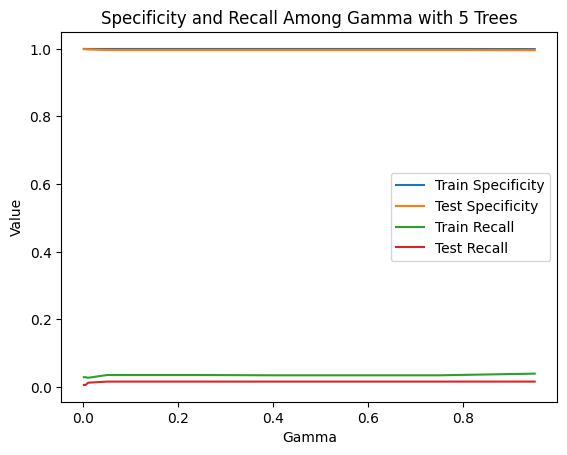

In [32]:
plotSpecRec(gamma, xgbHg, "Specificity and Recall Among Gamma with 5 Trees", "Gamma")

In [42]:
lam = [.001, .005,.01, .05, .1, .15, .25, .4, .5, .6, .75, .95]
xgbHlambda = makeStatsDictionary()

for l in lam:
  XGBmd = xgb.XGBClassifier(random_state = 42, class_weight = "balanced", reg_lambda = l, n_estimators = 5)
  getStats(XGBmd, xgbHlambda)

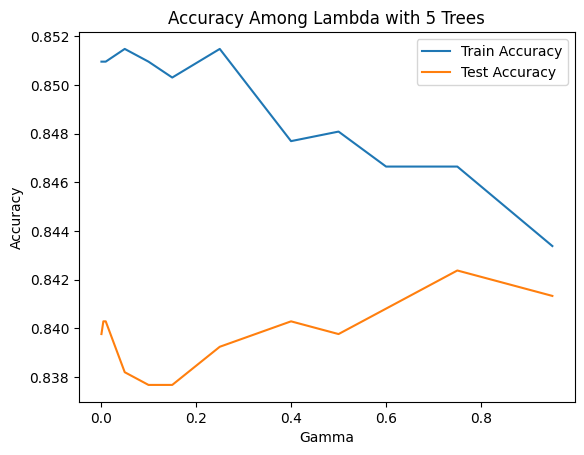

In [43]:
plotAccs(lam, xgbHlambda, "Accuracy Among Lambda with 5 Trees", "Lambda", True)

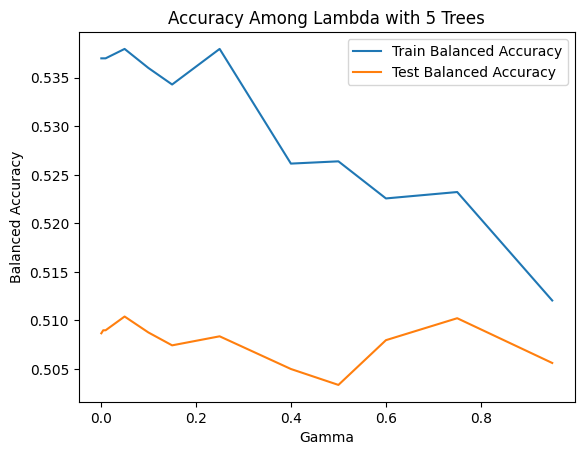

In [44]:
plotAccs(lam, xgbHlambda, "Accuracy Among Lambda with 5 Trees", "Lambda", False)

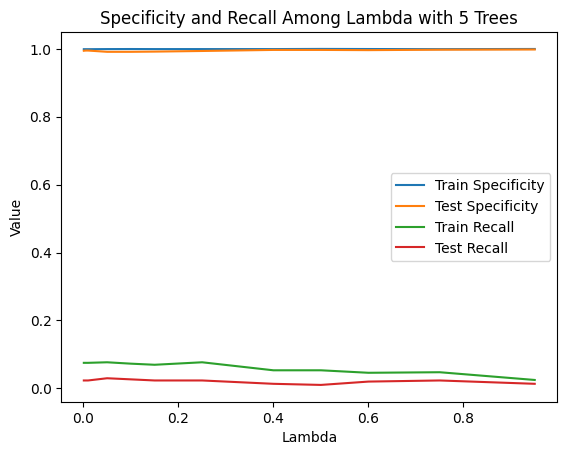

In [45]:
plotSpecRec(lam, xgbHlambda, "Specificity and Recall Among Lambda with 5 Trees", "Lambda")

In [46]:
xgbGrid = {'max_depth': [3, 4, 5],
          'learning_rate': [.1, .3, .5, .9],
          'gamma': [.1, .5, .75],
          'n_estimators': [5, 100, 200],
          'reg_lambda': [.1, .5, .75]}

#### For Balanced Accuracy

Classification report for XGBoost HTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      6434
           1       0.98      0.75      0.85      1228

    accuracy                           0.96      7662
   macro avg       0.97      0.87      0.91      7662
weighted avg       0.96      0.96      0.96      7662



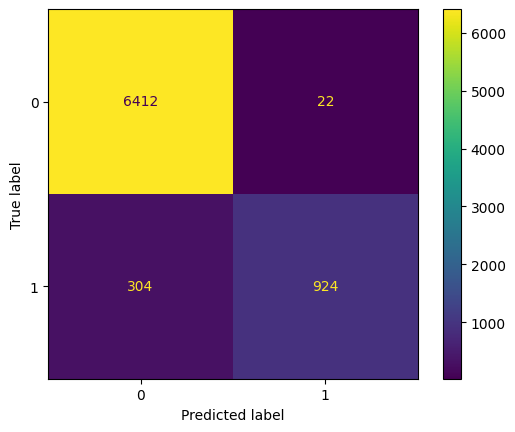

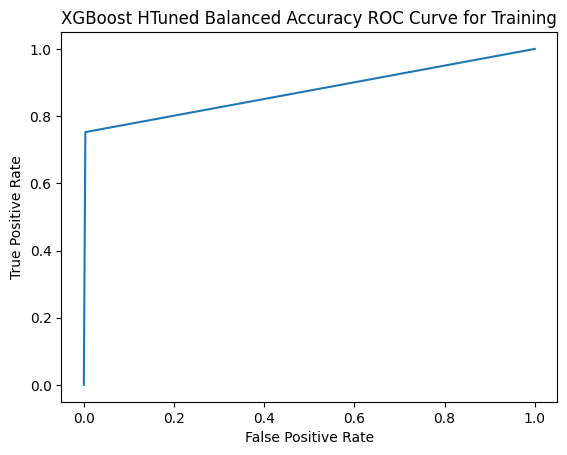

In [47]:
hMetric = 'Balanced Accuracy'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  xgbHbacc = GridSearchCV(xgb.XGBClassifier(random_state = 42, class_weight = 'balanced'), param_grid = xgbGrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  xgbHbacc = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')

viewTrainResults(name, xgbHbacc, hMetric, tMetric)

Classification report for XGBoost HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.85      0.92      0.88      1611
           1       0.25      0.14      0.18       305

    accuracy                           0.79      1916
   macro avg       0.55      0.53      0.53      1916
weighted avg       0.75      0.79      0.77      1916



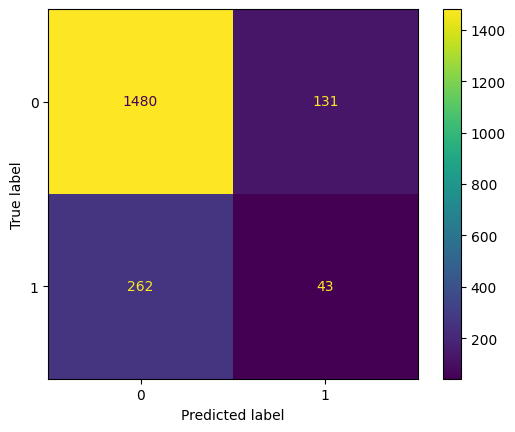

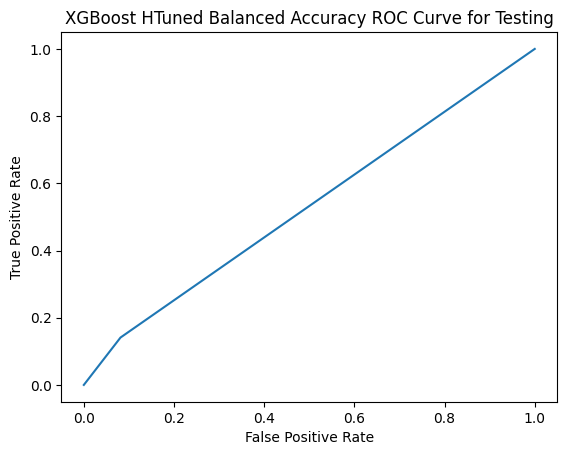

In [48]:
viewTestResults(name, xgbHbacc, hMetric, tMetric)

#### For Accuracy

Classification report for XGBoost HTuned Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      6434
           1       0.74      0.02      0.04      1228

    accuracy                           0.84      7662
   macro avg       0.79      0.51      0.48      7662
weighted avg       0.83      0.84      0.77      7662



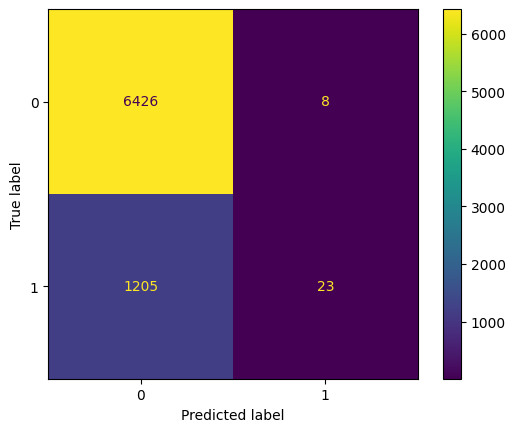

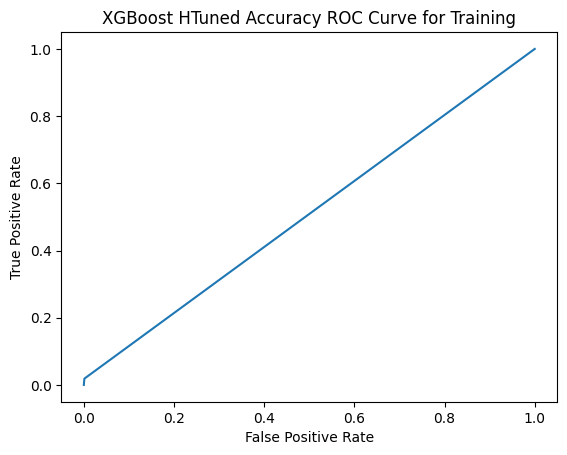

In [50]:
hMetric = 'Accuracy'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  xgbHacc = GridSearchCV(xgb.XGBClassifier(random_state = 42, class_weight = 'balanced'), param_grid = xgbGrid, n_jobs = -1, cv = 5)
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  xgbHacc = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5)

viewTrainResults(name, xgbHacc, hMetric, tMetric)

Classification report for XGBoost HTuned Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.50      0.02      0.03       305

    accuracy                           0.84      1916
   macro avg       0.67      0.51      0.47      1916
weighted avg       0.79      0.84      0.77      1916



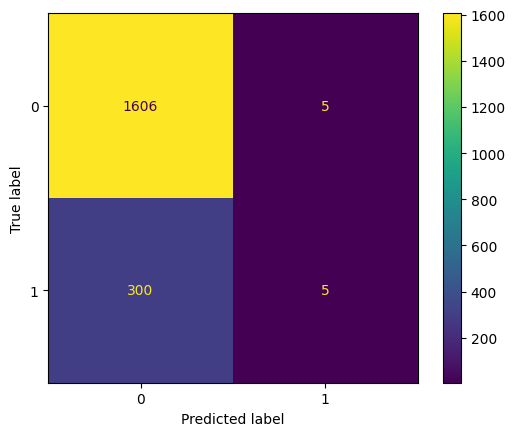

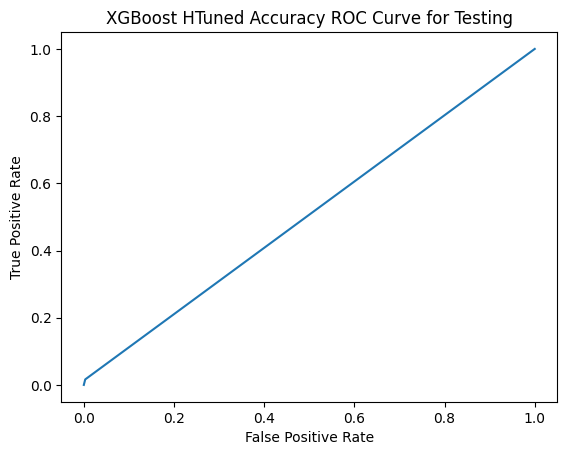

In [51]:
viewTestResults(name, xgbHacc, hMetric, tMetric)

#### For F1 Weighted

Classification report for XGBoost HTuned F1 Weighted training set 
 
               precision    recall  f1-score   support

           0       0.90      1.00      0.94      6434
           1       0.97      0.39      0.56      1228

    accuracy                           0.90      7662
   macro avg       0.93      0.69      0.75      7662
weighted avg       0.91      0.90      0.88      7662



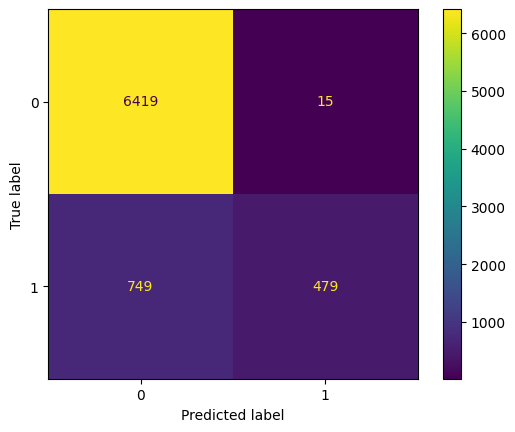

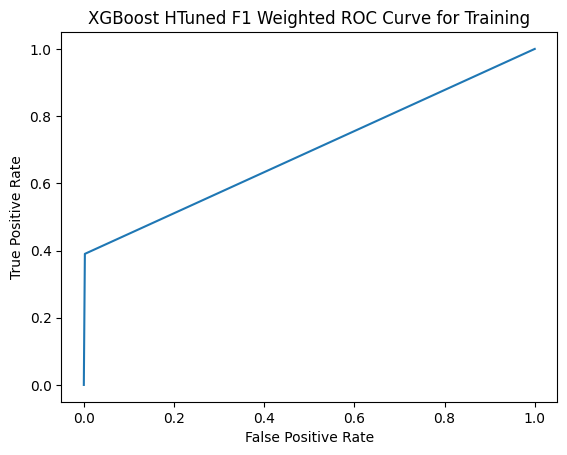

In [52]:
hMetric = 'F1 Weighted'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  xgbHf1w = GridSearchCV(xgb.XGBClassifier(random_state = 42, class_weight = 'balanced'), param_grid = xgbGrid, n_jobs = -1, cv = 5, scoring = 'f1_weighted')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  xgbHf1w = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'f1_weighted')

viewTrainResults(name, xgbHf1w, hMetric, tMetric)

Classification report for XGBoost HTuned F1 Weighted testing set 
 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90      1611
           1       0.35      0.10      0.15       305

    accuracy                           0.83      1916
   macro avg       0.60      0.53      0.53      1916
weighted avg       0.77      0.83      0.78      1916



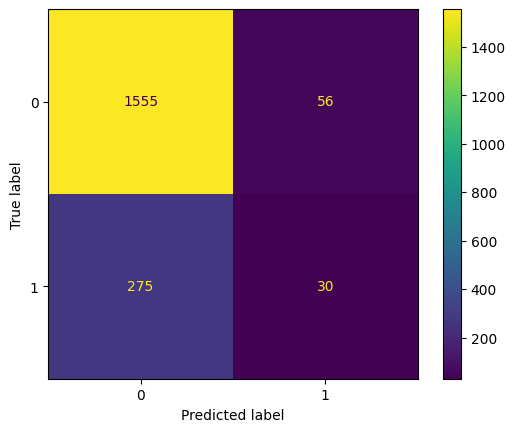

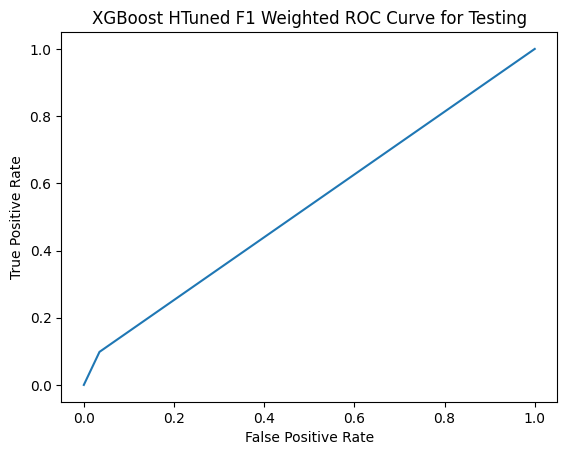

In [53]:
viewTestResults(name, xgbHf1w, hMetric, tMetric)

#### For Recall

Classification report for XGBoost HTuned Recall training set 
 
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      6434
           1       0.98      0.75      0.85      1228

    accuracy                           0.96      7662
   macro avg       0.97      0.87      0.91      7662
weighted avg       0.96      0.96      0.96      7662



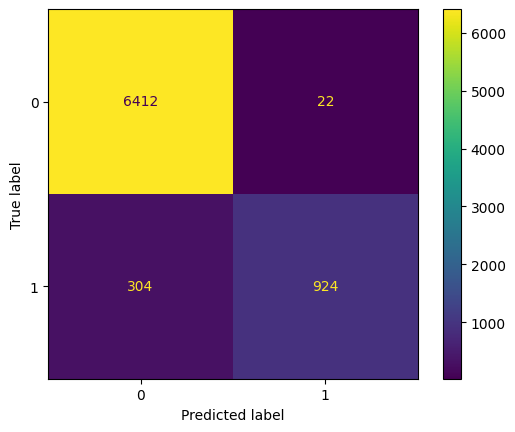

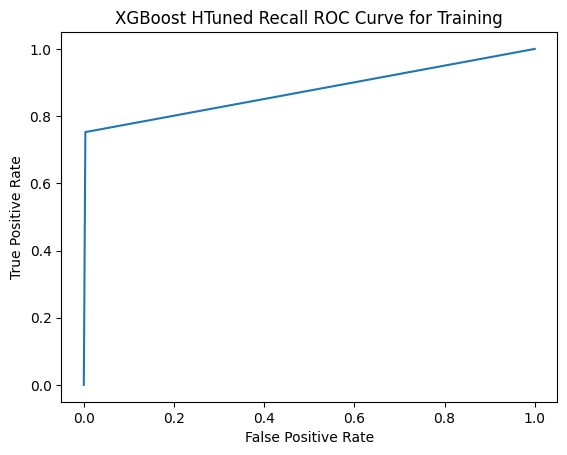

In [67]:
hMetric = 'Recall'

if len(checkExistence(statsTrain, name, hMetric, tMetric)) == 0:
  xgbHrec = GridSearchCV(xgb.XGBClassifier(random_state = 42, class_weight = 'balanced'), param_grid = xgbGrid, n_jobs = -1, cv = 5, scoring = 'recall')
else:
  pgrid = checkExistence(statsTrain, name, hMetric, tMetric).iloc[0, 2]
  for k, v in pgrid.items():
    if type(pgrid[k]) != list:
      pgrid[k] = [v]
  xgbHrec = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'), param_grid = pgrid, n_jobs = -1, cv = 5, scoring = 'recall')

viewTrainResults(name, xgbHrec, hMetric, tMetric)

Classification report for XGBoost HTuned Recall testing set 
 
               precision    recall  f1-score   support

           0       0.85      0.92      0.88      1611
           1       0.25      0.14      0.18       305

    accuracy                           0.79      1916
   macro avg       0.55      0.53      0.53      1916
weighted avg       0.75      0.79      0.77      1916



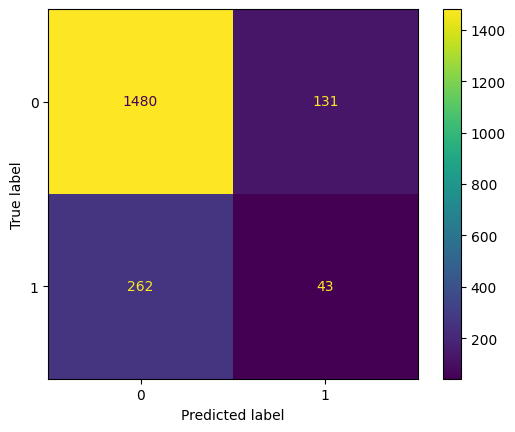

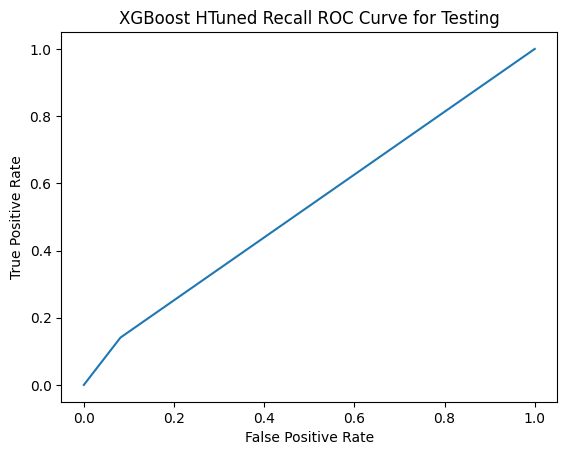

In [68]:
viewTestResults(name, xgbHrec, hMetric, tMetric)